### Experiment 9: Perceptron vs Multilayer Perceptron (A/B Experiment) with Hyperparameter Tuning
#### Isha Venkataraman - 3122247001023 (MTech Integrated CSE)

Aim: To implement a single-layer Perceptron Learning Algorithm (PLA) from scratch and a Multilayer Perceptron (MLP) trained with backpropagation on the English Handwritten Characters dataset (3,410 images, 62 classes), tune the MLP's activation function, optimizer, learning rate, batch size, architecture, loss function and regularization in a systematic way, and compare the two models using accuracy, precision, recall, F1-score, confusion matrices, micro/macro ROC curves and convergence curves

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
import time
import copy
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,
                             classification_report, roc_curve, auc, roc_auc_score)

IMG_DIR = "images"
os.makedirs(IMG_DIR, exist_ok=True)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
RNG = 42
np.random.seed(RNG)
torch.manual_seed(RNG)
torch.set_num_threads(max(1, os.cpu_count() - 1))
print(f"PyTorch {torch.__version__}, threads = {torch.get_num_threads()}")
print("Libraries imported successfully.")

PyTorch 2.10.0, threads = 10
Libraries imported successfully.


##### Loading the dataset and preprocessing the images
Each image is a 1200 x 900 RGB scan of a single handwritten character on a white background. Preprocessing: convert to grayscale, invert so that ink is bright, threshold to find the character's bounding box, place the crop on a square canvas with padding (so the aspect ratio is kept), resize to 32 x 32 with area interpolation and scale pixel values to [0, 1]. The 32 x 32 image is flattened to a 1,024-dimensional vector.

Preprocessed 3410 images in 24.6 s -> array shape (3410, 32, 32)
Feature matrix: (3410, 1024), classes: 62, pixel range: [0.00, 1.00]


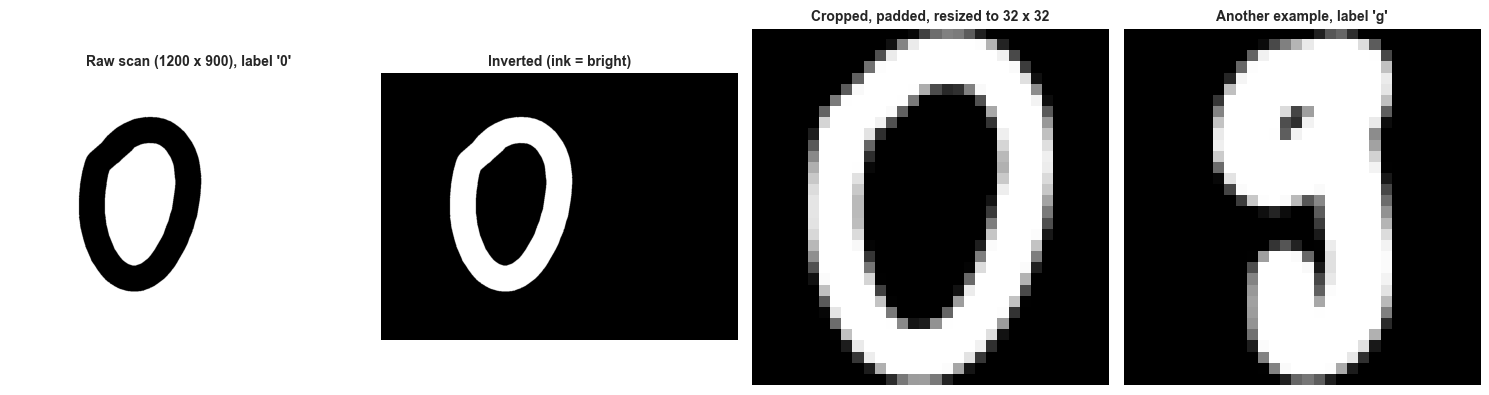

In [2]:
df = pd.read_csv("english.csv")
IMG_SIZE = 32
PAD = 8

def preprocess_image(path, size=IMG_SIZE, pad=PAD):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    inv = 255 - img
    _, mask = cv2.threshold(inv, 50, 255, cv2.THRESH_BINARY)
    ys, xs = np.where(mask > 0)
    if len(ys) == 0:
        crop = inv
    else:
        y0, y1, x0, x1 = ys.min(), ys.max(), xs.min(), xs.max()
        side = max(y1 - y0, x1 - x0) + 1 + 2 * pad
        cy, cx = (y0 + y1) // 2, (x0 + x1) // 2
        canvas = np.zeros((side, side), dtype=np.uint8)
        sy0, sx0 = max(cy - side // 2, 0), max(cx - side // 2, 0)
        sub = inv[sy0:sy0 + side, sx0:sx0 + side]
        oy, ox = (side - sub.shape[0]) // 2, (side - sub.shape[1]) // 2
        canvas[oy:oy + sub.shape[0], ox:ox + sub.shape[1]] = sub
        crop = canvas
    out = cv2.resize(crop, (size, size), interpolation=cv2.INTER_AREA)
    return out.astype(np.float32) / 255.0

t0 = time.time()
images = np.stack([preprocess_image(p) for p in df["image"]])
print(f"Preprocessed {len(images)} images in {time.time() - t0:.1f} s -> array shape {images.shape}")

le = LabelEncoder()
y_all = le.fit_transform(df["label"])
class_names = le.classes_
X_all = images.reshape(len(images), -1)
N_CLASSES = len(class_names)
N_FEATURES = X_all.shape[1]
print(f"Feature matrix: {X_all.shape}, classes: {N_CLASSES}, pixel range: [{X_all.min():.2f}, {X_all.max():.2f}]")

# raw vs preprocessed example
raw = cv2.imread(df["image"][0], cv2.IMREAD_GRAYSCALE)
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes[0].imshow(raw, cmap="gray"); axes[0].set_title(f"Raw scan (1200 x 900), label '{df['label'][0]}'", fontsize=10, fontweight="bold")
axes[1].imshow(255 - raw, cmap="gray"); axes[1].set_title("Inverted (ink = bright)", fontsize=10, fontweight="bold")
axes[2].imshow(images[0], cmap="gray"); axes[2].set_title("Cropped, padded, resized to 32 x 32", fontsize=10, fontweight="bold")
axes[3].imshow(images[df.index[df['label'] == 'g'][0]], cmap="gray"); axes[3].set_title("Another example, label 'g'", fontsize=10, fontweight="bold")
for ax in axes: ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "preprocessing_example.png"), dpi=300, bbox_inches="tight")
plt.show()

##### Dataset overview and class distribution
There are 3,410 images and 62 classes (10 digits, 26 uppercase and 26 lowercase letters) with exactly 55 images per class, so the dataset is perfectly balanced. There are no missing images or labels.

Images: 3410, missing image paths: 0, missing labels: 0
Files present on disk: True
Duplicate file names: 0
Images per class: min = 55, max = 55, classes = 62
Classes per group: {'upper': 26, 'lower': 26, 'digit': 10}


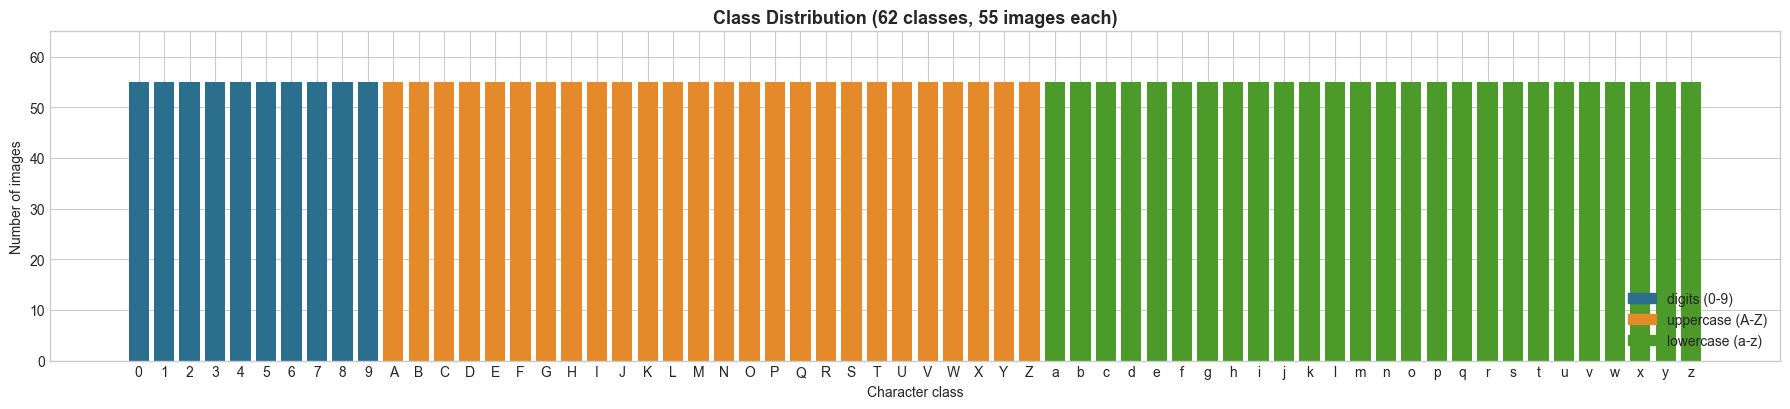

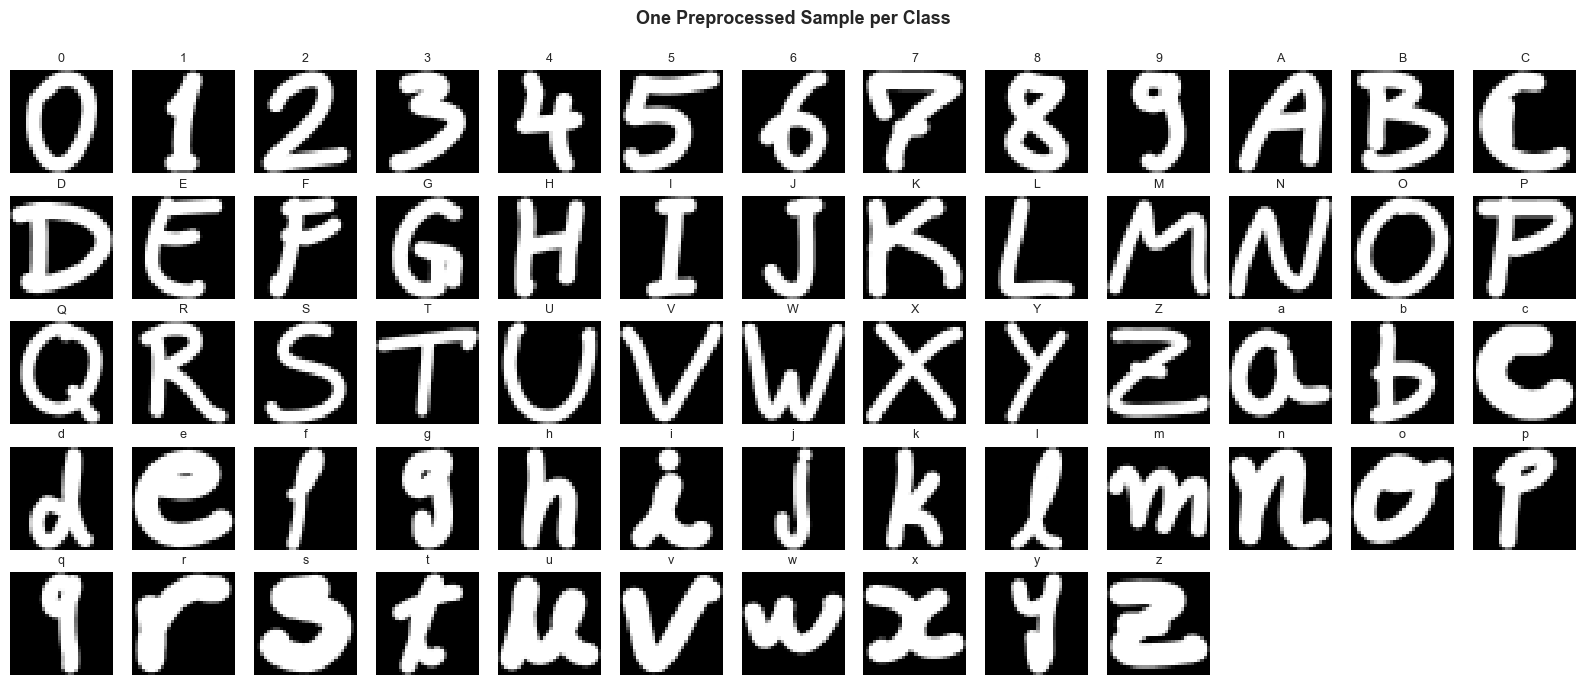

In [3]:
print(f"Images: {len(df)}, missing image paths: {df['image'].isnull().sum()}, missing labels: {df['label'].isnull().sum()}")
print(f"Files present on disk: {all(os.path.exists(p) for p in df['image'])}")
print(f"Duplicate file names: {df['image'].duplicated().sum()}")
counts = df["label"].value_counts()
print(f"Images per class: min = {counts.min()}, max = {counts.max()}, classes = {len(counts)}")

group = np.array(["digit" if c.isdigit() else ("upper" if c.isupper() else "lower") for c in class_names])
print("Classes per group:", pd.Series(group).value_counts().to_dict())

fig, ax = plt.subplots(figsize=(18, 4.2))
colors = ["#2C6E8E" if g == "digit" else ("#E58A2A" if g == "upper" else "#4C9A2A") for g in group]
ax.bar(class_names, counts.reindex(class_names).values, color=colors)
ax.set_title("Class Distribution (62 classes, 55 images each)", fontsize=13, fontweight="bold")
ax.set_xlabel("Character class"); ax.set_ylabel("Number of images"); ax.set_ylim(0, 65)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#2C6E8E", label="digits (0-9)"), Patch(color="#E58A2A", label="uppercase (A-Z)"), Patch(color="#4C9A2A", label="lowercase (a-z)")], loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "class_distribution.png"), dpi=300, bbox_inches="tight")
plt.show()

# one preprocessed sample per class
fig, axes = plt.subplots(5, 13, figsize=(16, 6.8))
for i, ax in enumerate(axes.flatten()):
    if i < N_CLASSES:
        idx = np.where(y_all == i)[0][0]
        ax.imshow(images[idx], cmap="gray"); ax.set_title(class_names[i], fontsize=9)
    ax.axis("off")
plt.suptitle("One Preprocessed Sample per Class", y=1.0, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "sample_grid.png"), dpi=300, bbox_inches="tight")
plt.show()

##### Statistical summary and feature distributions
Pixel intensity statistics, the ink fraction (share of non-background pixels) per class group and the average image of a few classes. Average images show that classes such as 'O', 'o' and '0' or 'l', 'I' and '1' are almost identical after normalisation, which is where most confusions will come from.

Per-image statistics by class group:


Group                 digit     lower     upper
Pixel mean   count  550.000  1430.000  1430.000
             mean     0.285     0.313     0.289
             std      0.078     0.098     0.076
             min      0.113     0.096     0.095
             25%      0.231     0.247     0.235
             50%      0.283     0.308     0.287
             75%      0.334     0.379     0.341
             max      0.577     0.617     0.513
Pixel std    count  550.000  1430.000  1430.000
             mean     0.420     0.429     0.420
             std      0.037     0.042     0.036
             min      0.295     0.276     0.277
             25%      0.399     0.409     0.398
             50%      0.426     0.439     0.426
             75%      0.448     0.463     0.448
             max      0.479     0.483     0.481
Ink fraction count  550.000  1430.000  1430.000
             mean     0.320     0.345     0.327
             std      0.081     0.102     0.080
             min      0.133     0.115     0.108
             25%      0.261     0.277     0.271
             50%      0.320     0.340     0.326
             75%      0.372     0.415     0.384
             max      0.606     0.661     0.554

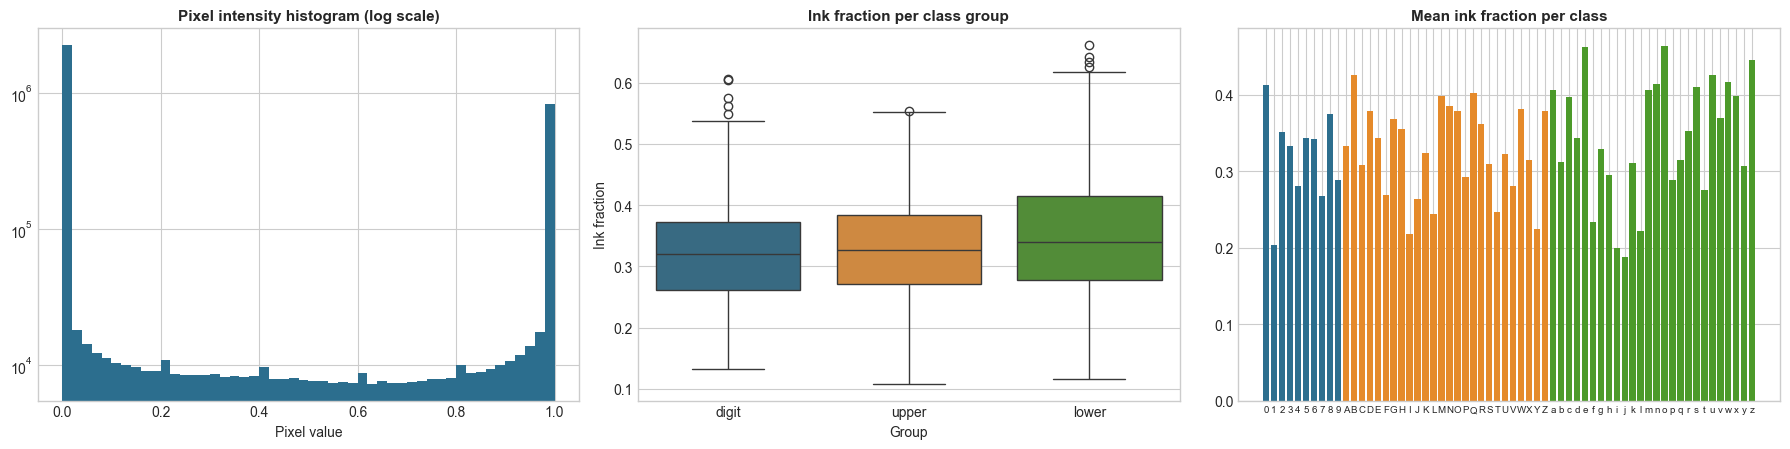

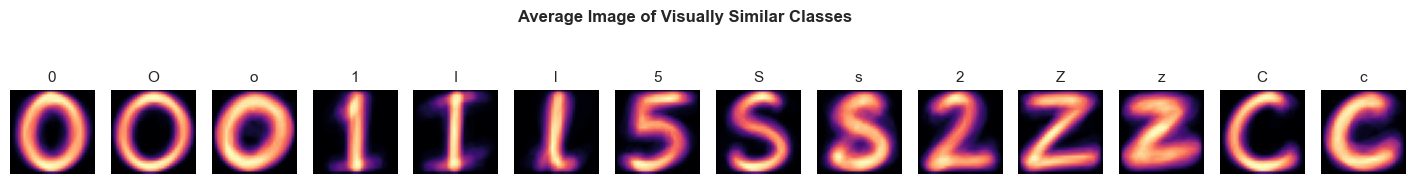

In [4]:
ink = (X_all > 0.2).mean(axis=1)
stats = pd.DataFrame({"Pixel mean": X_all.mean(axis=1), "Pixel std": X_all.std(axis=1), "Ink fraction": ink,
                      "Group": [{"digit": "digit", "upper": "upper", "lower": "lower"}[group[c]] for c in y_all]})
print("Per-image statistics by class group:")
display(stats.groupby("Group")[["Pixel mean", "Pixel std", "Ink fraction"]].describe().round(3).T)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.6))
axes[0].hist(X_all.ravel(), bins=50, color="#2C6E8E", log=True)
axes[0].set_title("Pixel intensity histogram (log scale)", fontsize=11, fontweight="bold"); axes[0].set_xlabel("Pixel value")
sns.boxplot(data=stats, x="Group", y="Ink fraction", order=["digit", "upper", "lower"], palette=["#2C6E8E", "#E58A2A", "#4C9A2A"], ax=axes[1])
axes[1].set_title("Ink fraction per class group", fontsize=11, fontweight="bold")
per_class_ink = pd.Series(ink).groupby(y_all).mean()
axes[2].bar(class_names, per_class_ink.values, color=colors)
axes[2].set_title("Mean ink fraction per class", fontsize=11, fontweight="bold"); axes[2].tick_params(axis="x", labelsize=7)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "feature_distributions.png"), dpi=300, bbox_inches="tight")
plt.show()

show = ["0", "O", "o", "1", "I", "l", "5", "S", "s", "2", "Z", "z", "C", "c"]
fig, axes = plt.subplots(1, len(show), figsize=(18, 2.2))
for ax, ch in zip(axes, show):
    ax.imshow(images[y_all == le.transform([ch])[0]].mean(axis=0), cmap="magma"); ax.set_title(ch, fontsize=11); ax.axis("off")
plt.suptitle("Average Image of Visually Similar Classes", y=1.05, fontsize=12, fontweight="bold")
plt.savefig(os.path.join(IMG_DIR, "average_images.png"), dpi=300, bbox_inches="tight")
plt.show()

##### Correlation structure and PCA view of the data
Neighbouring pixels are strongly correlated, which is shown with a correlation matrix of 64 block-mean features (each block is 4 x 4 pixels). The PCA scatter shows that the 62 classes overlap heavily in the leading directions, so a linear model has little chance of separating them all.

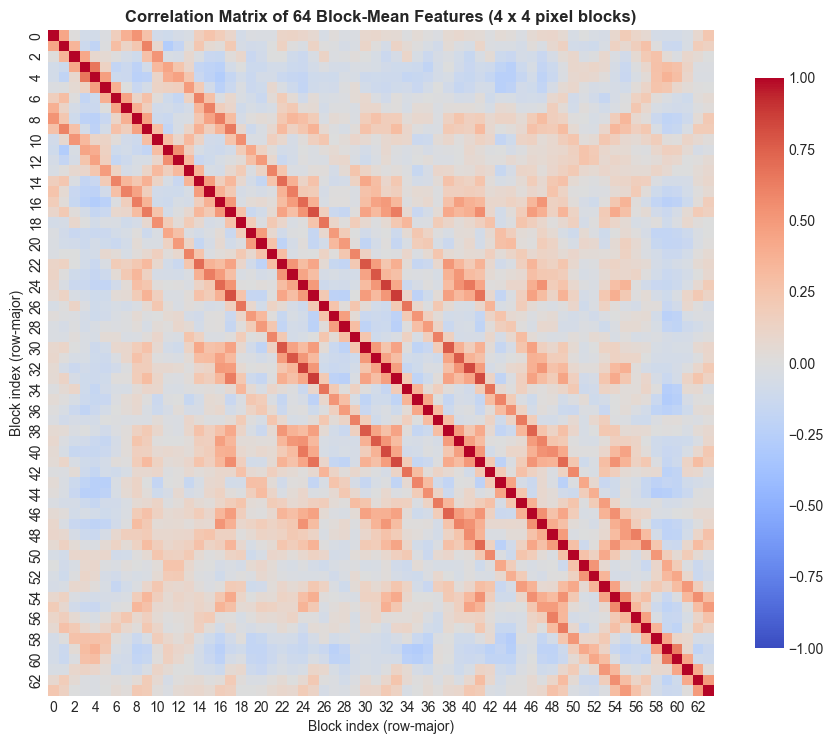

Block-feature pairs with |r| > 0.5: 3.4%, mean |r| = 0.138
Variance explained by 2 / 10 / 50 components: 19.4% / 51.1% / 85.8%


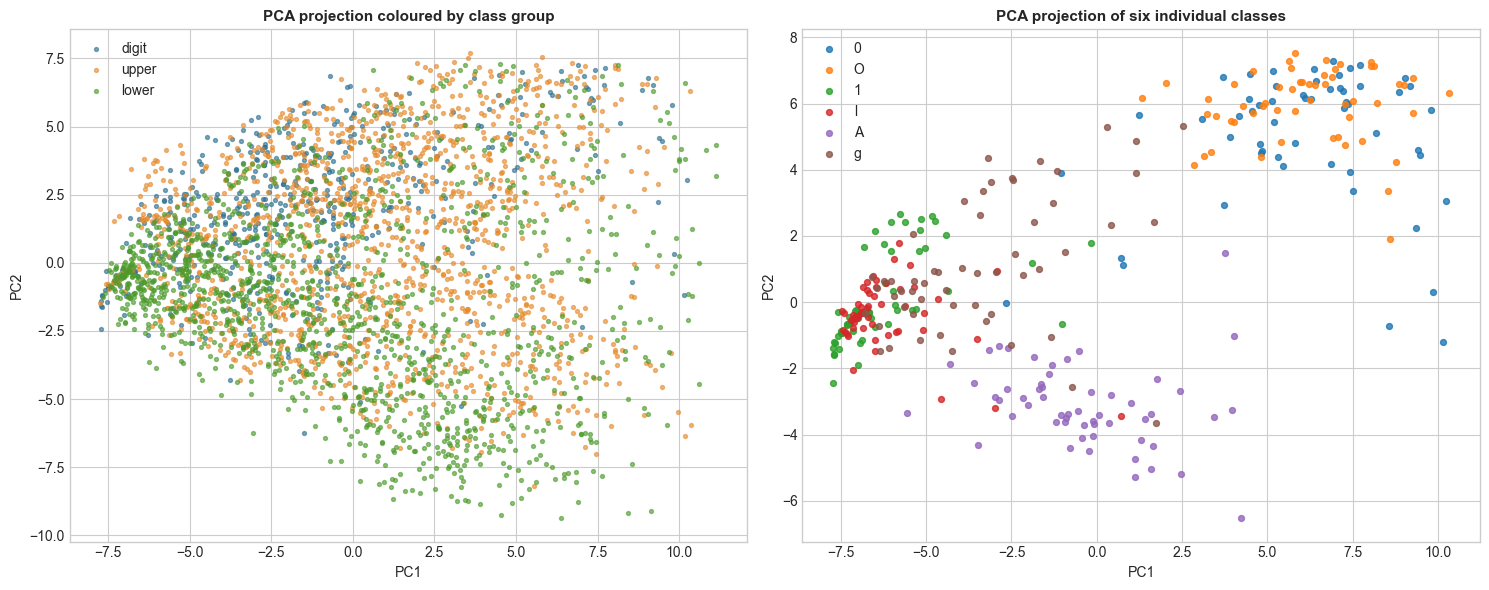

In [5]:
blocks = images.reshape(len(images), 8, 4, 8, 4).mean(axis=(2, 4)).reshape(len(images), 64)
block_corr = np.corrcoef(blocks, rowvar=False)
fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(block_corr, cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True, ax=ax, cbar_kws={"shrink": 0.75})
ax.set_title("Correlation Matrix of 64 Block-Mean Features (4 x 4 pixel blocks)", fontsize=12, fontweight="bold")
ax.set_xlabel("Block index (row-major)"); ax.set_ylabel("Block index (row-major)")
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "correlation_matrix.png"), dpi=300, bbox_inches="tight")
plt.show()
upper = block_corr[np.triu_indices(64, k=1)]
print(f"Block-feature pairs with |r| > 0.5: {(np.abs(upper) > 0.5).mean()*100:.1f}%, mean |r| = {np.abs(upper).mean():.3f}")

pca = PCA(n_components=50, random_state=RNG).fit(X_all)
X_p = pca.transform(X_all)
print(f"Variance explained by 2 / 10 / 50 components: {pca.explained_variance_ratio_[:2].sum()*100:.1f}% / {pca.explained_variance_ratio_[:10].sum()*100:.1f}% / {pca.explained_variance_ratio_.sum()*100:.1f}%")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
grp_colors = {"digit": "#2C6E8E", "upper": "#E58A2A", "lower": "#4C9A2A"}
for g in ["digit", "upper", "lower"]:
    m = group[y_all] == g
    axes[0].scatter(X_p[m, 0], X_p[m, 1], s=8, alpha=0.6, color=grp_colors[g], label=g)
axes[0].set_title("PCA projection coloured by class group", fontsize=11, fontweight="bold"); axes[0].legend()
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
for ch, c in zip(["0", "O", "1", "l", "A", "g"], sns.color_palette("tab10", 6)):
    m = y_all == le.transform([ch])[0]
    axes[1].scatter(X_p[m, 0], X_p[m, 1], s=18, alpha=0.8, color=c, label=ch)
axes[1].set_title("PCA projection of six individual classes", fontsize=11, fontweight="bold"); axes[1].legend()
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "pca_projection.png"), dpi=300, bbox_inches="tight")
plt.show()

##### Train / validation / test split
A stratified 80/20 split gives 11 test images per class. From the remaining 44 per class, 7 go to a validation set used for hyperparameter tuning and early stopping, leaving 37 per class for training. Both PLA and MLP see exactly the same training data and the test set is used only once at the end.

In [6]:
X_trval, X_test, y_trval, y_test = train_test_split(X_all, y_all, test_size=0.2, stratify=y_all, random_state=RNG)
X_train, X_val, y_train, y_val = train_test_split(X_trval, y_trval, test_size=7/44, stratify=y_trval, random_state=RNG)
print(f"Train: {X_train.shape[0]} ({np.bincount(y_train).min()}-{np.bincount(y_train).max()} per class)")
print(f"Validation: {X_val.shape[0]} ({np.bincount(y_val).min()}-{np.bincount(y_val).max()} per class)")
print(f"Test: {X_test.shape[0]} ({np.bincount(y_test).min()}-{np.bincount(y_test).max()} per class)")
Y_test_bin = label_binarize(y_test, classes=np.arange(N_CLASSES))

Train: 2294 (37-37 per class)
Validation: 434 (7-7 per class)
Test: 682 (11-11 per class)


##### Model A: Perceptron Learning Algorithm from scratch
A single layer of 62 perceptrons, one per class (one-vs-rest), each with a step activation. For every training sample the 62 units fire (1) or not (0), the one-hot target is compared with the output and the classic update w = w + eta (y - y_hat) x is applied to every unit that is wrong. The class prediction is the unit with the largest net input. Training error and validation accuracy are recorded after every epoch, and the weights from the epoch with the best validation accuracy are kept (the pocket idea), because on data that is not linearly separable the raw PLA never settles.

In [7]:
class Perceptron:
    def __init__(self, n_features, n_classes, eta=1.0, epochs=50, seed=RNG):
        self.eta, self.epochs, self.seed = eta, epochs, seed
        self.W = np.zeros((n_classes, n_features + 1))
        self.n_classes = n_classes
        self.history = {"train_err": [], "val_err": [], "updates": []}

    @staticmethod
    def _bias(X):
        return np.hstack([X, np.ones((len(X), 1), dtype=X.dtype)])

    def net_input(self, X):
        return self._bias(X) @ self.W.T

    def predict(self, X):
        return np.argmax(self.net_input(X), axis=1)

    def fit(self, X, y, X_val=None, y_val=None, verbose=True):
        Xb = self._bias(X)
        T = np.eye(self.n_classes)[y]
        rng = np.random.RandomState(self.seed)
        best_val, self.best_W, self.best_epoch = -1, self.W.copy(), 0
        for ep in range(1, self.epochs + 1):
            n_updates = 0
            for i in rng.permutation(len(Xb)):
                x = Xb[i]
                y_hat = (self.W @ x > 0).astype(float)      # step activation
                delta = T[i] - y_hat                          # (y - y_hat) for each unit
                if np.any(delta != 0):
                    self.W += self.eta * np.outer(delta, x)   # w <- w + eta (y - y_hat) x
                    n_updates += 1
            tr_err = 1 - accuracy_score(y, self.predict(X))
            self.history["train_err"].append(tr_err); self.history["updates"].append(n_updates)
            if X_val is not None:
                va_err = 1 - accuracy_score(y_val, self.predict(X_val))
                self.history["val_err"].append(va_err)
                if 1 - va_err > best_val:
                    best_val, self.best_W, self.best_epoch = 1 - va_err, self.W.copy(), ep
            if verbose and (ep % 10 == 0 or ep == 1):
                print(f"epoch {ep:3d}: updates = {n_updates:5d}, train error = {tr_err:.4f}" + (f", val error = {va_err:.4f}" if X_val is not None else ""))
            if n_updates == 0:
                print(f"Converged (no updates) at epoch {ep}")
                break
        self.final_W = self.W.copy()
        return self

t0 = time.time()
pla = Perceptron(N_FEATURES, N_CLASSES, eta=1.0, epochs=60).fit(X_train, y_train, X_val, y_val)
pla_time = time.time() - t0
print(f"\nPLA training time: {pla_time:.1f} s, best validation epoch = {pla.best_epoch}")
print(f"Final-epoch weights: train acc = {accuracy_score(y_train, pla.predict(X_train)):.4f}, val acc = {accuracy_score(y_val, pla.predict(X_val)):.4f}")
pla.W = pla.best_W
print(f"Best-validation weights (epoch {pla.best_epoch}): train acc = {accuracy_score(y_train, pla.predict(X_train)):.4f}, val acc = {accuracy_score(y_val, pla.predict(X_val)):.4f}")

epoch   1: updates =  1926, train error = 0.4486, val error = 0.4770


epoch  10: updates =   963, train error = 0.1465, val error = 0.4009


epoch  20: updates =   493, train error = 0.0615, val error = 0.3548


epoch  30: updates =   208, train error = 0.0262, val error = 0.3249


epoch  40: updates =    72, train error = 0.0131, val error = 0.3157


epoch  50: updates =    19, train error = 0.0039, val error = 0.2903


epoch  60: updates =    19, train error = 0.0026, val error = 0.2903

PLA training time: 3.3 s, best validation epoch = 38
Final-epoch weights: train acc = 0.9974, val acc = 0.7097
Best-validation weights (epoch 38): train acc = 0.9908, val acc = 0.7120


##### PLA convergence curves and learning rate check
The training error keeps falling because the 1,024-dimensional training set is almost linearly separable, but the validation error stalls early and oscillates. With zero initial weights the PLA is invariant to the learning rate: scaling eta scales every weight by the same factor and neither the step threshold nor the argmax changes, which the table confirms.

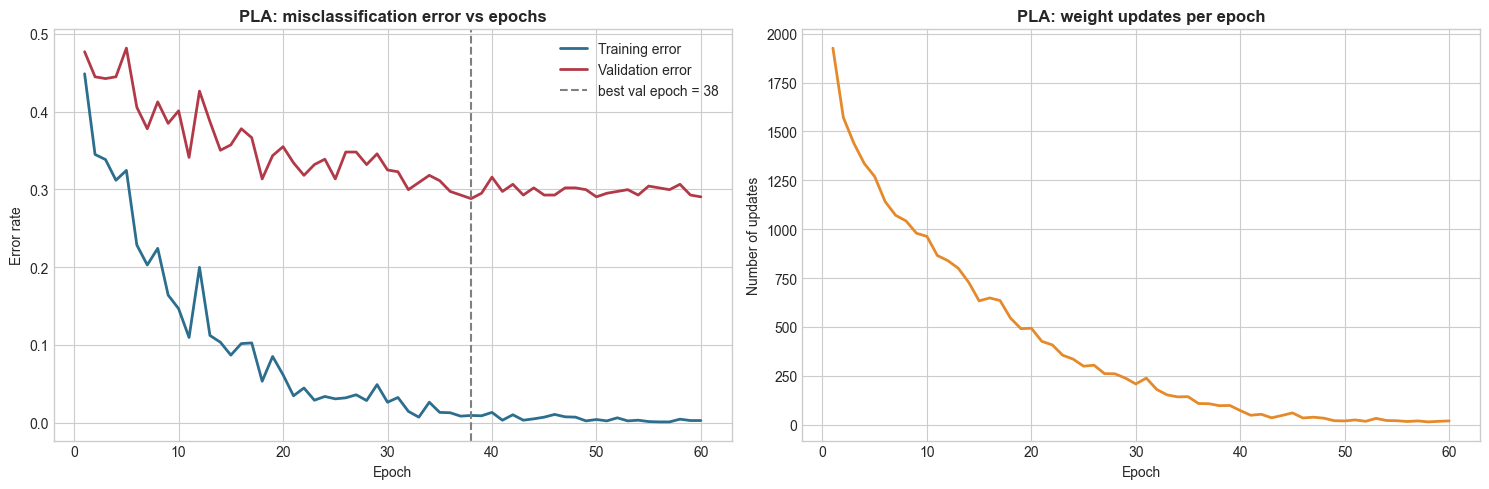

PLA learning-rate check (zero initialisation, 20 epochs):


,eta,Train error (epoch 20),Best val accuracy,Best epoch,Mean |w|
0,0.01,0.0615,0.6866,18,0.0521
1,0.10,0.0615,0.6866,18,0.5212
2,1.00,0.0615,0.6866,18,5.2120
3,10.00,0.0615,0.6866,18,52.1203


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ep = np.arange(1, len(pla.history["train_err"]) + 1)
axes[0].plot(ep, pla.history["train_err"], color="#2C6E8E", linewidth=2, label="Training error")
axes[0].plot(ep, pla.history["val_err"], color="#B23A48", linewidth=2, label="Validation error")
axes[0].axvline(pla.best_epoch, color="gray", linestyle="--", label=f"best val epoch = {pla.best_epoch}")
axes[0].set_title("PLA: misclassification error vs epochs", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Error rate"); axes[0].legend()
axes[1].plot(ep, pla.history["updates"], color="#E58A2A", linewidth=2)
axes[1].set_title("PLA: weight updates per epoch", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Number of updates")
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "pla_convergence.png"), dpi=300, bbox_inches="tight")
plt.show()

eta_rows = []
for eta in [0.01, 0.1, 1.0, 10.0]:
    p = Perceptron(N_FEATURES, N_CLASSES, eta=eta, epochs=20).fit(X_train, y_train, X_val, y_val, verbose=False)
    eta_rows.append({"eta": eta, "Train error (epoch 20)": p.history["train_err"][-1], "Best val accuracy": 1 - min(p.history["val_err"]), "Best epoch": p.best_epoch, "Mean |w|": np.abs(p.final_W).mean()})
eta_df = pd.DataFrame(eta_rows).round(4)
print("PLA learning-rate check (zero initialisation, 20 epochs):")
display(eta_df)

##### PLA evaluation on the test set

PLA test metrics:


,Model,Accuracy,Precision (macro),Recall (macro),F1 (macro),F1 (weighted),ROC-AUC (micro),ROC-AUC (macro)
0,PLA,0.6437,0.6651,0.6437,0.6395,0.6395,0.9588,0.96


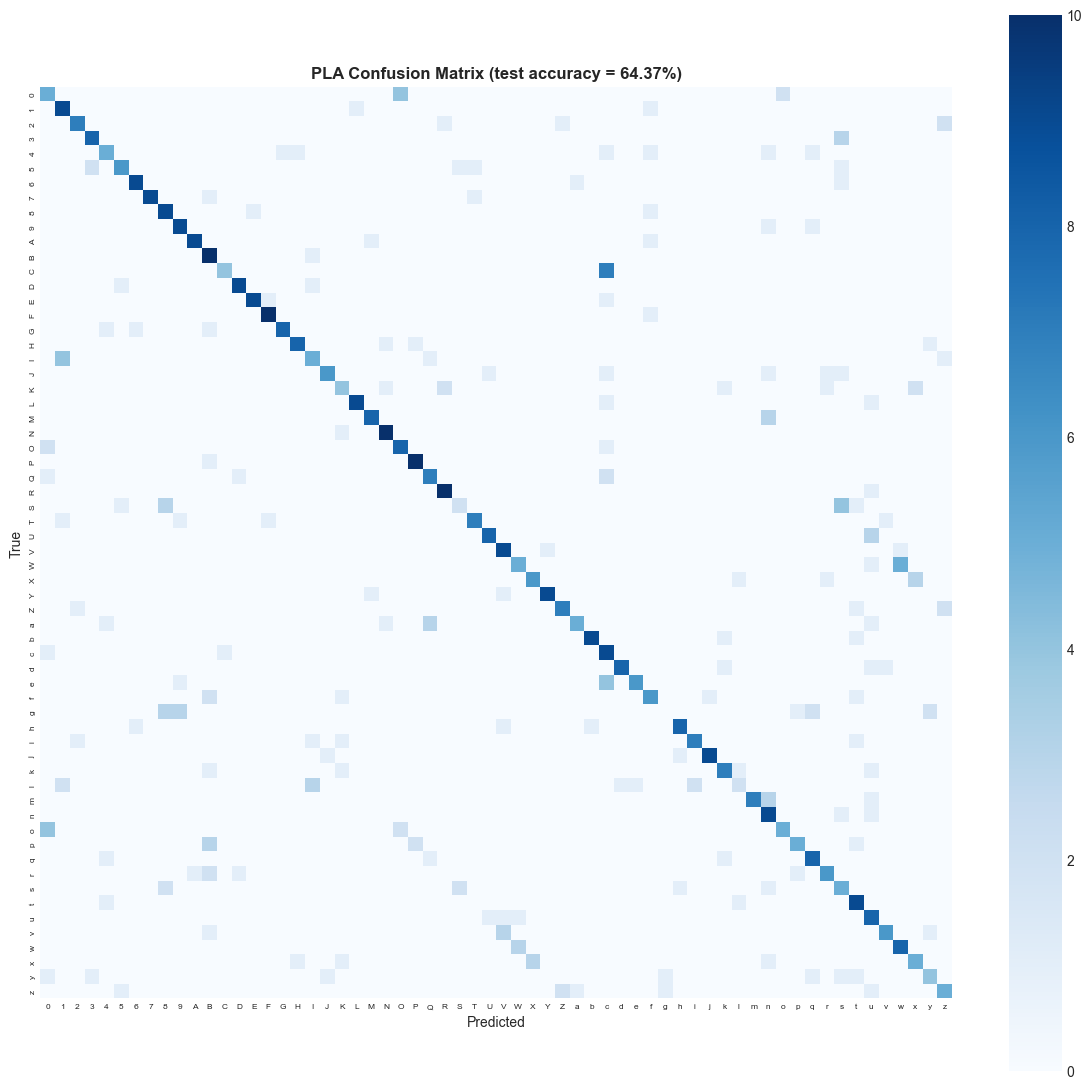

Most frequent PLA confusions:


,True,Predicted,Count
0,C,c,7
1,W,w,5
2,0,O,4
3,e,c,4
4,o,0,4
5,S,s,4
6,I,1,4
7,l,I,3
8,X,x,3
9,S,8,3


In [9]:
def evaluate_model(name, y_true, y_pred, scores):
    Y_bin = label_binarize(y_true, classes=np.arange(N_CLASSES))
    return {"Model": name,
            "Accuracy": accuracy_score(y_true, y_pred),
            "Precision (macro)": precision_score(y_true, y_pred, average="macro", zero_division=0),
            "Recall (macro)": recall_score(y_true, y_pred, average="macro", zero_division=0),
            "F1 (macro)": f1_score(y_true, y_pred, average="macro", zero_division=0),
            "F1 (weighted)": f1_score(y_true, y_pred, average="weighted", zero_division=0),
            "ROC-AUC (micro)": roc_auc_score(Y_bin, scores, average="micro"),
            "ROC-AUC (macro)": roc_auc_score(Y_bin, scores, average="macro")}

def roc_micro_macro(y_true, scores):
    Y_bin = label_binarize(y_true, classes=np.arange(N_CLASSES))
    fpr_mi, tpr_mi, _ = roc_curve(Y_bin.ravel(), scores.ravel())
    all_fpr = np.linspace(0, 1, 500)
    mean_tpr = np.zeros_like(all_fpr)
    for c in range(N_CLASSES):
        fpr_c, tpr_c, _ = roc_curve(Y_bin[:, c], scores[:, c])
        mean_tpr += np.interp(all_fpr, fpr_c, tpr_c)
    mean_tpr /= N_CLASSES
    return (fpr_mi, tpr_mi, auc(fpr_mi, tpr_mi)), (all_fpr, mean_tpr, auc(all_fpr, mean_tpr))

def plot_confusion(ax, y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(N_CLASSES))
    sns.heatmap(cm, cmap="Blues", ax=ax, cbar=True, xticklabels=class_names, yticklabels=class_names, square=True, linewidths=0)
    ax.set_title(title, fontsize=12, fontweight="bold"); ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.tick_params(axis="both", labelsize=6)
    return cm

def top_confusions(cm, n=10):
    off = cm.copy(); np.fill_diagonal(off, 0)
    idx = np.dstack(np.unravel_index(np.argsort(-off.ravel()), off.shape))[0][:n]
    return pd.DataFrame([{"True": class_names[i], "Predicted": class_names[j], "Count": off[i, j]} for i, j in idx])

pla_scores = pla.net_input(X_test)
pla_pred = pla.predict(X_test)
pla_metrics = evaluate_model("PLA", y_test, pla_pred, pla_scores)
print("PLA test metrics:")
display(pd.DataFrame([pla_metrics]).round(4))

fig, ax = plt.subplots(figsize=(12, 11))
cm_pla = plot_confusion(ax, y_test, pla_pred, f"PLA Confusion Matrix (test accuracy = {pla_metrics['Accuracy']*100:.2f}%)")
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "pla_confusion_matrix.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Most frequent PLA confusions:")
display(top_confusions(cm_pla))

##### Model B: Multilayer Perceptron in PyTorch
A fully connected network: 1,024 inputs, one or more hidden layers with a non-linear activation (and optional dropout), and a 62-unit output layer. Training uses mini-batch backpropagation with a chosen optimizer and loss (cross-entropy on the logits, or mean squared error on the softmax output against one-hot targets). Early stopping on the validation error restores the best weights. Every tuning configuration is trained with three seeds and the mean validation accuracy is reported so that the choice is not driven by one lucky run.

In [10]:
ACTS = {"relu": nn.ReLU, "tanh": nn.Tanh, "sigmoid": nn.Sigmoid}

class MLP(nn.Module):
    def __init__(self, hidden=(256,), activation="relu", dropout=0.0, n_in=N_FEATURES, n_out=N_CLASSES):
        super().__init__()
        layers, d = [], n_in
        for h in hidden:
            layers += [nn.Linear(d, h), ACTS[activation]()]
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            d = h
        layers.append(nn.Linear(d, n_out))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

Xtr_t, ytr_t = torch.tensor(X_train), torch.tensor(y_train, dtype=torch.long)
Xva_t, yva_t = torch.tensor(X_val), torch.tensor(y_val, dtype=torch.long)
Xte_t, yte_t = torch.tensor(X_test), torch.tensor(y_test, dtype=torch.long)

def make_loss(kind):
    if kind == "cross_entropy":
        ce = nn.CrossEntropyLoss()
        return lambda logits, y: ce(logits, y)
    if kind == "mse":
        return lambda logits, y: F.mse_loss(F.softmax(logits, dim=1), F.one_hot(y, N_CLASSES).float()) * N_CLASSES
    raise ValueError(kind)

def make_optimizer(params, name, lr, weight_decay=0.0):
    if name == "sgd":
        return torch.optim.SGD(params, lr=lr, weight_decay=weight_decay)
    if name == "sgd_momentum":
        return torch.optim.SGD(params, lr=lr, momentum=0.9, weight_decay=weight_decay)
    if name == "adam":
        return torch.optim.Adam(params, lr=lr, weight_decay=weight_decay)
    raise ValueError(name)

def augment_images(Xnp, rng, max_angle=12, scale=(0.9, 1.1), max_shift=2):
    # small random rotation, scaling and translation of each 32 x 32 image
    imgs = Xnp.reshape(-1, IMG_SIZE, IMG_SIZE)
    out = np.empty_like(imgs)
    for i, im in enumerate(imgs):
        M = cv2.getRotationMatrix2D((IMG_SIZE / 2, IMG_SIZE / 2), rng.uniform(-max_angle, max_angle), rng.uniform(*scale))
        M[:, 2] += rng.uniform(-max_shift, max_shift, 2)
        out[i] = cv2.warpAffine(im, M, (IMG_SIZE, IMG_SIZE), flags=cv2.INTER_LINEAR, borderValue=0)
    return out.reshape(len(Xnp), -1)

def train_mlp(hidden=(256,), activation="relu", optimizer="adam", lr=1e-3, batch_size=64, loss="cross_entropy",
              dropout=0.0, weight_decay=0.0, epochs=60, patience=10, augment=False, seed=RNG, Xtr=None, ytr=None, Xva=None, yva=None, verbose=False):
    Xtr = Xtr_t if Xtr is None else Xtr; ytr = ytr_t if ytr is None else ytr
    Xva = Xva_t if Xva is None else Xva; yva = yva_t if yva is None else yva
    torch.manual_seed(seed); np.random.seed(seed)
    rng = np.random.RandomState(seed)
    Xtr_np = Xtr.numpy()
    model = MLP(hidden, activation, dropout)
    opt = make_optimizer(model.parameters(), optimizer, lr, weight_decay)
    loss_fn = make_loss(loss)
    hist = {"train_loss": [], "train_err": [], "val_loss": [], "val_err": []}
    best = {"val_err": 1.0, "epoch": 0, "state": copy.deepcopy(model.state_dict())}
    n = len(Xtr); wait = 0; t0 = time.time()
    for ep in range(1, epochs + 1):
        model.train()
        Xep = torch.tensor(augment_images(Xtr_np, rng)) if augment else Xtr
        perm = torch.randperm(n)
        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]
            opt.zero_grad()
            l = loss_fn(model(Xep[idx]), ytr[idx])
            l.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            out_tr, out_va = model(Xtr), model(Xva)
            hist["train_loss"].append(loss_fn(out_tr, ytr).item()); hist["train_err"].append((out_tr.argmax(1) != ytr).float().mean().item())
            hist["val_loss"].append(loss_fn(out_va, yva).item()); hist["val_err"].append((out_va.argmax(1) != yva).float().mean().item())
        if hist["val_err"][-1] < best["val_err"]:
            best = {"val_err": hist["val_err"][-1], "epoch": ep, "state": copy.deepcopy(model.state_dict())}; wait = 0
        else:
            wait += 1
        if verbose and (ep % 10 == 0 or ep == 1):
            print(f"epoch {ep:3d}: train loss {hist['train_loss'][-1]:.4f} err {hist['train_err'][-1]:.4f} | val loss {hist['val_loss'][-1]:.4f} err {hist['val_err'][-1]:.4f}")
        if wait >= patience:
            break
    model.load_state_dict(best["state"]); model.eval()
    return {"model": model, "history": hist, "best_epoch": best["epoch"], "val_acc": 1 - best["val_err"],
            "train_acc": 1 - hist["train_err"][best["epoch"] - 1], "epochs_run": len(hist["val_err"]), "time": time.time() - t0,
            "params": sum(p.numel() for p in model.parameters())}

def run_config(label, seeds=(0, 1, 2), **kw):
    runs = [train_mlp(seed=s, **kw) for s in seeds]
    return {"Config": label, "Val accuracy (mean)": np.mean([r["val_acc"] for r in runs]), "Val accuracy (std)": np.std([r["val_acc"] for r in runs]),
            "Train accuracy": np.mean([r["train_acc"] for r in runs]), "Best epoch": np.mean([r["best_epoch"] for r in runs]),
            "Time (s)": np.mean([r["time"] for r in runs]), "Params": runs[0]["params"], "_runs": runs}

def show_table(rows, title):
    df_ = pd.DataFrame([{k: v for k, v in r.items() if k != "_runs"} for r in rows])
    df_["Gap (train - val)"] = df_["Train accuracy"] - df_["Val accuracy (mean)"]
    print(title)
    display(df_.round(4))
    return df_

BASE = dict(hidden=(256,), activation="relu", optimizer="adam", lr=1e-3, batch_size=64, loss="cross_entropy", dropout=0.0, weight_decay=0.0, epochs=60, patience=10)
print("Baseline configuration:", BASE)

Baseline configuration: {'hidden': (256,), 'activation': 'relu', 'optimizer': 'adam', 'lr': 0.001, 'batch_size': 64, 'loss': 'cross_entropy', 'dropout': 0.0, 'weight_decay': 0.0, 'epochs': 60, 'patience': 10}


##### Tuning stage 1: activation function
ReLU, tanh and sigmoid with everything else fixed at the baseline (one hidden layer of 256 units, Adam, lr = 0.001, batch 64, cross-entropy).

Stage 1: activation function (3 seeds)


,Config,Val accuracy (mean),Val accuracy (std),Train accuracy,Best epoch,Time (s),Params,Gap (train - val)
0,relu,0.7972,0.0050,0.9696,21.6667,1.1672,278334,0.1724
1,tanh,0.7965,0.0047,0.9788,24.3333,1.2942,278334,0.1823
2,sigmoid,0.7888,0.0115,0.9337,25.3333,1.3068,278334,0.1450


Selected activation: relu


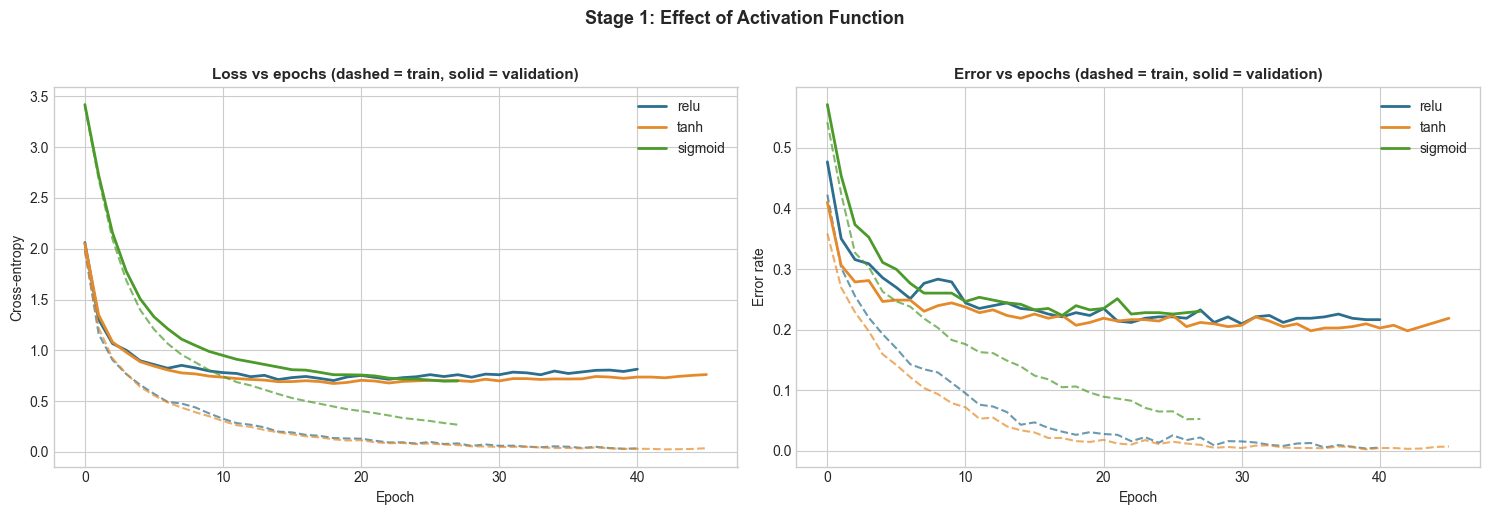

In [11]:
stage1 = [run_config(act, **{**BASE, "activation": act}) for act in ["relu", "tanh", "sigmoid"]]
stage1_df = show_table(stage1, "Stage 1: activation function (3 seeds)")
best_act = stage1[int(np.argmax([r["Val accuracy (mean)"] for r in stage1]))]["Config"]
print(f"Selected activation: {best_act}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for r, c in zip(stage1, ["#2C6E8E", "#E58A2A", "#4C9A2A"]):
    h = r["_runs"][0]["history"]
    axes[0].plot(h["train_loss"], color=c, linestyle="--", alpha=0.7); axes[0].plot(h["val_loss"], color=c, linewidth=2, label=r["Config"])
    axes[1].plot(h["train_err"], color=c, linestyle="--", alpha=0.7); axes[1].plot(h["val_err"], color=c, linewidth=2, label=r["Config"])
axes[0].set_title("Loss vs epochs (dashed = train, solid = validation)", fontsize=11, fontweight="bold"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Cross-entropy"); axes[0].legend()
axes[1].set_title("Error vs epochs (dashed = train, solid = validation)", fontsize=11, fontweight="bold"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Error rate"); axes[1].legend()
plt.suptitle("Stage 1: Effect of Activation Function", y=1.02, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "tuning_activation.png"), dpi=300, bbox_inches="tight")
plt.show()

##### Tuning stage 2: optimizer and learning rate
Plain SGD, SGD with momentum 0.9 and Adam, each over its own sensible range of learning rates, because the best learning rate is optimizer dependent.

Stage 2: optimizer x learning rate (3 seeds)


,Config,Val accuracy (mean),Val accuracy (std),Train accuracy,Best epoch,Time (s),Params,Optimizer,lr,Gap (train - val)
0,"sgd, lr=0.01",0.7296,0.0078,0.7700,51.6667,1.0108,278334,sgd,0.0100,0.0403
1,"sgd, lr=0.05",0.7719,0.0068,0.8612,31.0000,0.7448,278334,sgd,0.0500,0.0893
2,"sgd, lr=0.1",0.7811,0.0132,0.9236,29.6667,0.8133,278334,sgd,0.1000,0.1425
3,"sgd, lr=0.3",0.8018,0.0065,0.9653,23.6667,0.6444,278334,sgd,0.3000,0.1634
4,"sgd_momentum, lr=0.005",0.7880,0.0075,0.9092,44.3333,1.2869,278334,sgd_momentum,0.0050,0.1212
5,"sgd_momentum, lr=0.01",0.7865,0.0054,0.9000,23.3333,0.8009,278334,sgd_momentum,0.0100,0.1135
6,"sgd_momentum, lr=0.05",0.8065,0.0019,0.9927,29.0000,0.8440,278334,sgd_momentum,0.0500,0.1863
7,"sgd_momentum, lr=0.1",0.7911,0.0076,0.9753,19.6667,0.6695,278334,sgd_momentum,0.1000,0.1842
8,"adam, lr=0.0001",0.7642,0.0043,0.8864,55.6667,1.9053,278334,adam,0.0001,0.1222
9,"adam, lr=0.0005",0.7896,0.0066,0.9638,28.0000,1.2056,278334,adam,0.0005,0.1743


Selected optimizer: sgd_momentum, learning rate: 0.05


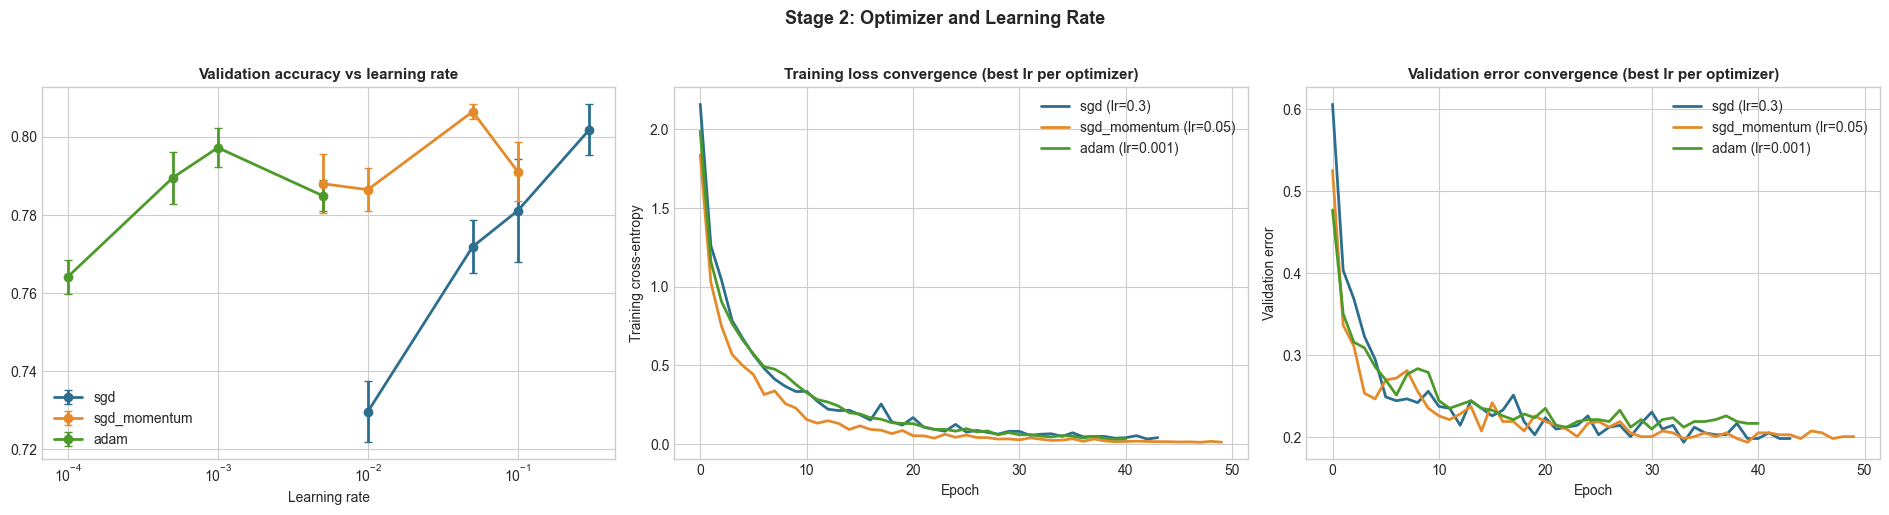

In [12]:
opt_grid = {"sgd": [0.01, 0.05, 0.1, 0.3], "sgd_momentum": [0.005, 0.01, 0.05, 0.1], "adam": [1e-4, 5e-4, 1e-3, 5e-3]}
stage2 = []
for opt_name, lrs in opt_grid.items():
    for lr in lrs:
        r = run_config(f"{opt_name}, lr={lr}", **{**BASE, "activation": best_act, "optimizer": opt_name, "lr": lr})
        r["Optimizer"], r["lr"] = opt_name, lr
        stage2.append(r)
stage2_df = show_table(stage2, "Stage 2: optimizer x learning rate (3 seeds)")
best2 = stage2[int(np.argmax([r["Val accuracy (mean)"] for r in stage2]))]
best_opt, best_lr = best2["Optimizer"], best2["lr"]
print(f"Selected optimizer: {best_opt}, learning rate: {best_lr}")

# best learning rate per optimizer for the convergence comparison
best_per_opt = {o: max([r for r in stage2 if r["Optimizer"] == o], key=lambda r: r["Val accuracy (mean)"]) for o in opt_grid}
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
piv = stage2_df.assign(Optimizer=[r["Optimizer"] for r in stage2], lr=[r["lr"] for r in stage2])
for o, c in zip(opt_grid, ["#2C6E8E", "#E58A2A", "#4C9A2A"]):
    sub = piv[piv["Optimizer"] == o]
    axes[0].errorbar(sub["lr"], sub["Val accuracy (mean)"], yerr=sub["Val accuracy (std)"], marker="o", color=c, linewidth=2, capsize=3, label=o)
    h = best_per_opt[o]["_runs"][0]["history"]
    axes[1].plot(h["train_loss"], color=c, linewidth=2, label=f"{o} (lr={best_per_opt[o]['lr']})")
    axes[2].plot(h["val_err"], color=c, linewidth=2, label=f"{o} (lr={best_per_opt[o]['lr']})")
axes[0].set_xscale("log"); axes[0].set_title("Validation accuracy vs learning rate", fontsize=11, fontweight="bold"); axes[0].set_xlabel("Learning rate"); axes[0].legend()
axes[1].set_title("Training loss convergence (best lr per optimizer)", fontsize=11, fontweight="bold"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Training cross-entropy"); axes[1].legend()
axes[2].set_title("Validation error convergence (best lr per optimizer)", fontsize=11, fontweight="bold"); axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Validation error"); axes[2].legend()
plt.suptitle("Stage 2: Optimizer and Learning Rate", y=1.02, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "tuning_optimizer_lr.png"), dpi=300, bbox_inches="tight")
plt.show()

##### Tuning stage 3: batch size
Smaller batches mean more (noisier) updates per epoch; larger batches are faster per epoch but need more epochs.

Stage 3: batch size (3 seeds)


,Config,Val accuracy (mean),Val accuracy (std),Train accuracy,Best epoch,Time (s),Params,Gap (train - val)
0,batch=16,0.5998,0.0093,0.6915,15.0000,1.9267,278334,0.0917
1,batch=32,0.8126,0.0071,0.9942,30.3333,1.5666,278334,0.1816
2,batch=64,0.8065,0.0019,0.9927,29.0000,0.9598,278334,0.1863
3,batch=128,0.7949,0.0019,0.9705,21.3333,0.5044,278334,0.1756
4,batch=256,0.7796,0.0022,0.8806,16.3333,0.3212,278334,0.1010


Selected batch size: 32
Validation error trajectory for batch = 16 (first seed): [0.588, 0.47, 0.505, 0.5, 0.44, 0.521, 0.454, 0.438, 0.424, 0.507, 0.465, 0.419, 0.406, 0.461, 0.477, 0.468, 0.431, 0.468, 0.461, 0.5, 0.468, 0.491, 0.463]
Training loss trajectory for batch = 16 (first seed): [1.887, 1.352, 1.673, 1.624, 1.363, 1.642, 1.579, 1.264, 1.274, 1.627, 1.547, 1.265, 1.258, 1.536, 1.263, 1.45, 1.391, 1.265, 1.373, 2.138, 1.612, 1.697, 1.58]


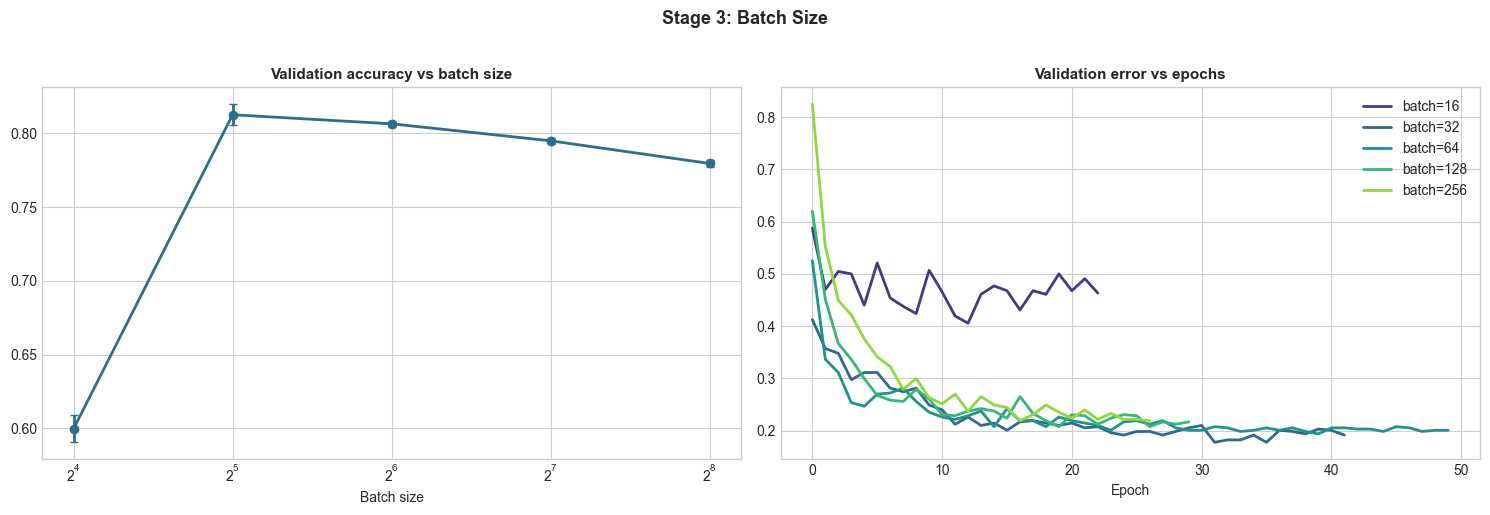

In [13]:
stage3 = [run_config(f"batch={bs}", **{**BASE, "activation": best_act, "optimizer": best_opt, "lr": best_lr, "batch_size": bs}) for bs in [16, 32, 64, 128, 256]]
stage3_df = show_table(stage3, "Stage 3: batch size (3 seeds)")
best_bs = [16, 32, 64, 128, 256][int(np.argmax([r["Val accuracy (mean)"] for r in stage3]))]
print(f"Selected batch size: {best_bs}")
print("Validation error trajectory for batch = 16 (first seed):", np.round(stage3[0]["_runs"][0]["history"]["val_err"], 3).tolist())
print("Training loss trajectory for batch = 16 (first seed):", np.round(stage3[0]["_runs"][0]["history"]["train_loss"], 3).tolist())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].errorbar([16, 32, 64, 128, 256], stage3_df["Val accuracy (mean)"], yerr=stage3_df["Val accuracy (std)"], marker="o", color="#2C6E8E", linewidth=2, capsize=3)
axes[0].set_xscale("log", base=2); axes[0].set_title("Validation accuracy vs batch size", fontsize=11, fontweight="bold"); axes[0].set_xlabel("Batch size")
for r, c in zip(stage3, sns.color_palette("viridis", 5)):
    axes[1].plot(r["_runs"][0]["history"]["val_err"], color=c, linewidth=2, label=r["Config"])
axes[1].set_title("Validation error vs epochs", fontsize=11, fontweight="bold"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.suptitle("Stage 3: Batch Size", y=1.02, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "tuning_batch_size.png"), dpi=300, bbox_inches="tight")
plt.show()

##### Tuning stage 4: number of hidden layers and neurons
Widths of 128 to 1,024 with one hidden layer, and two or three hidden layers, to see whether depth helps on 2,300 training images.

Stage 4: architecture (3 seeds)


,Config,Val accuracy (mean),Val accuracy (std),Train accuracy,Best epoch,Time (s),Params,Gap (train - val)
0,"(128,)",0.7849,0.0207,0.9741,23.6667,1.0371,139198,0.1892
1,"(256,)",0.8126,0.0071,0.9942,30.3333,1.5409,278334,0.1816
2,"(512,)",0.8103,0.0057,0.9711,13.6667,1.1372,556606,0.1608
3,"(1024,)",0.8103,0.0022,0.9799,21.6667,2.8122,1113150,0.1697
4,"(256, 128)",0.7581,0.0050,0.9108,19.0000,1.3167,303294,0.1527
5,"(512, 256)",0.7957,0.0217,0.9725,25.3333,2.3959,672062,0.1768
6,"(512, 256, 128)",0.7412,0.0054,0.8750,20.3333,2.4178,697022,0.1339
7,"(256, 256, 256)",0.7512,0.0050,0.8845,18.0000,2.0267,409918,0.1333


Selected architecture: (256,)


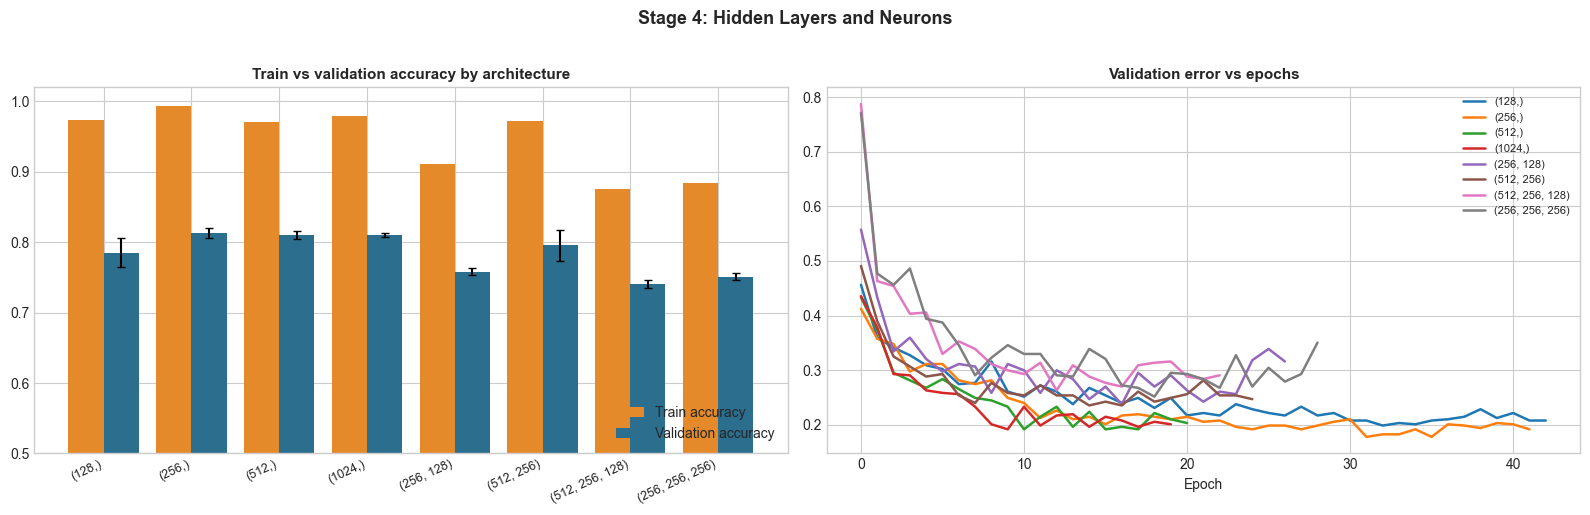

In [14]:
archs = [(128,), (256,), (512,), (1024,), (256, 128), (512, 256), (512, 256, 128), (256, 256, 256)]
stage4 = [run_config(str(a), **{**BASE, "activation": best_act, "optimizer": best_opt, "lr": best_lr, "batch_size": best_bs, "hidden": a}) for a in archs]
stage4_df = show_table(stage4, "Stage 4: architecture (3 seeds)")
best_arch = archs[int(np.argmax([r["Val accuracy (mean)"] for r in stage4]))]
print(f"Selected architecture: {best_arch}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
x = np.arange(len(archs))
axes[0].bar(x - 0.2, stage4_df["Train accuracy"], 0.4, color="#E58A2A", label="Train accuracy")
axes[0].bar(x + 0.2, stage4_df["Val accuracy (mean)"], 0.4, yerr=stage4_df["Val accuracy (std)"], color="#2C6E8E", label="Validation accuracy", capsize=3)
axes[0].set_xticks(x); axes[0].set_xticklabels([str(a) for a in archs], rotation=25, ha="right", fontsize=9)
axes[0].set_ylim(0.5, 1.02); axes[0].set_title("Train vs validation accuracy by architecture", fontsize=11, fontweight="bold"); axes[0].legend(loc="lower right")
for r, c in zip(stage4, sns.color_palette("tab10", len(archs))):
    axes[1].plot(r["_runs"][0]["history"]["val_err"], color=c, linewidth=1.8, label=r["Config"])
axes[1].set_title("Validation error vs epochs", fontsize=11, fontweight="bold"); axes[1].set_xlabel("Epoch"); axes[1].legend(fontsize=8)
plt.suptitle("Stage 4: Hidden Layers and Neurons", y=1.02, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "tuning_architecture.png"), dpi=300, bbox_inches="tight")
plt.show()

##### Tuning stage 5: cost function
Cross-entropy on the logits versus mean squared error between the softmax output and the one-hot target.

Stage 5: loss function (3 seeds)


,Config,Val accuracy (mean),Val accuracy (std),Train accuracy,Best epoch,Time (s),Params,Gap (train - val)
0,cross_entropy,0.8126,0.0071,0.9942,30.3333,1.6128,278334,0.1816
1,mse,0.7911,0.0029,0.9393,26.0000,1.5756,278334,0.1482


Selected loss: cross_entropy


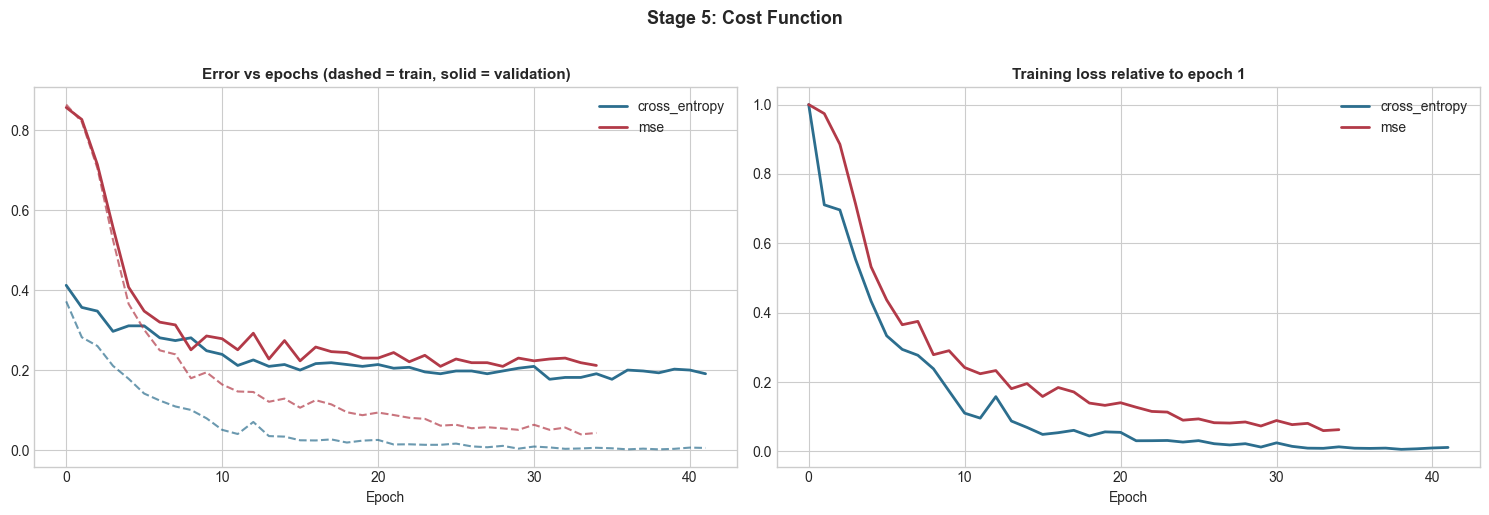

In [15]:
stage5 = [run_config(l, **{**BASE, "activation": best_act, "optimizer": best_opt, "lr": best_lr, "batch_size": best_bs, "hidden": best_arch, "loss": l}) for l in ["cross_entropy", "mse"]]
stage5_df = show_table(stage5, "Stage 5: loss function (3 seeds)")
best_loss = ["cross_entropy", "mse"][int(np.argmax([r["Val accuracy (mean)"] for r in stage5]))]
print(f"Selected loss: {best_loss}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for r, c in zip(stage5, ["#2C6E8E", "#B23A48"]):
    h = r["_runs"][0]["history"]
    axes[0].plot(h["train_err"], color=c, linestyle="--", alpha=0.7); axes[0].plot(h["val_err"], color=c, linewidth=2, label=r["Config"])
    axes[1].plot(np.array(h["train_loss"]) / h["train_loss"][0], color=c, linewidth=2, label=r["Config"])
axes[0].set_title("Error vs epochs (dashed = train, solid = validation)", fontsize=11, fontweight="bold"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].set_title("Training loss relative to epoch 1", fontsize=11, fontweight="bold"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.suptitle("Stage 5: Cost Function", y=1.02, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "tuning_loss.png"), dpi=300, bbox_inches="tight")
plt.show()

##### Tuning stage 6: regularization against overfitting
All configurations so far reach almost 100% training accuracy while validation accuracy is far lower, which is overfitting. Dropout and L2 weight decay are tried, alone and together.

Stage 6: regularization (3 seeds, up to 100 epochs)


,Config,Val accuracy (mean),Val accuracy (std),Train accuracy,Best epoch,Time (s),Params,dropout,weight_decay,Gap (train - val)
0,none,0.8134,0.0068,0.9939,34.3333,1.9000,278334,0.0,0.0000,0.1805
1,dropout 0.2,0.7873,0.0029,0.9730,36.3333,2.1551,278334,0.2,0.0000,0.1857
2,dropout 0.4,0.7089,0.0093,0.8330,24.3333,1.6453,278334,0.4,0.0000,0.1241
3,weight decay 1e-4,0.8157,0.0050,0.9910,29.6667,1.8616,278334,0.0,0.0001,0.1753
4,weight decay 1e-3,0.7980,0.0066,0.9823,26.0000,1.6673,278334,0.0,0.0010,0.1843
5,dropout 0.2 + wd 1e-4,0.7919,0.0060,0.9661,38.6667,2.2117,278334,0.2,0.0001,0.1743
6,dropout 0.4 + wd 1e-4,0.7243,0.0228,0.8333,25.6667,1.7546,278334,0.4,0.0001,0.1091


Selected regularization: dropout = 0.0, weight decay = 0.0001


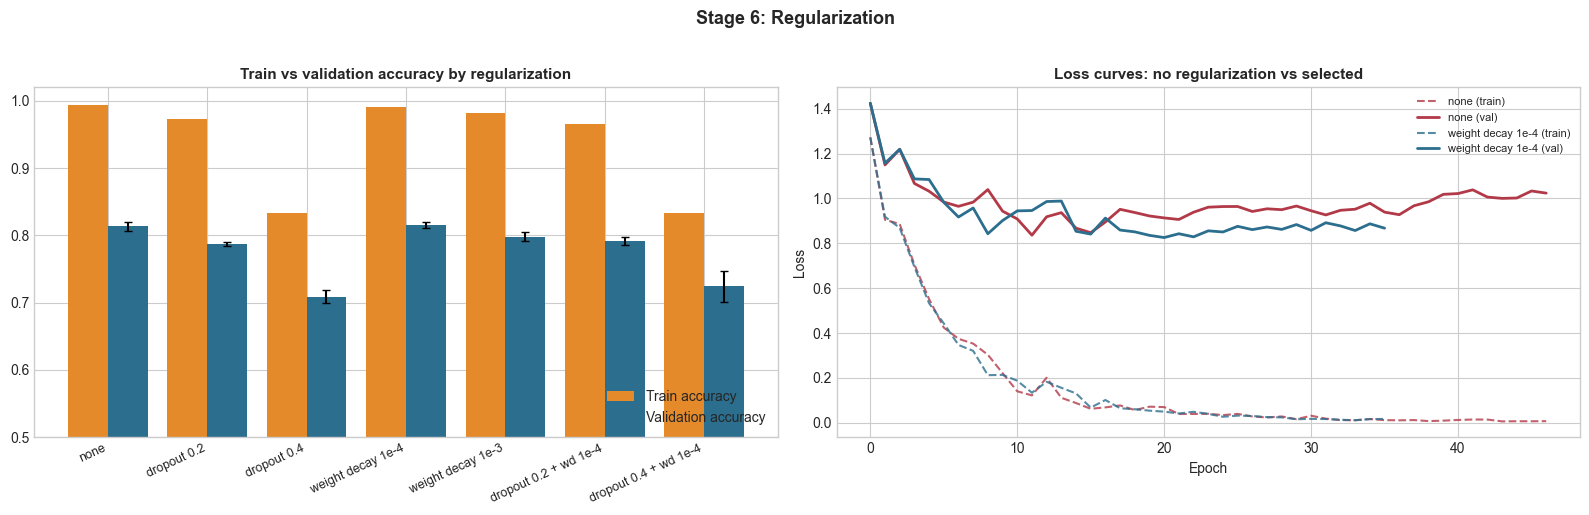

In [16]:
reg_grid = [("none", 0.0, 0.0), ("dropout 0.2", 0.2, 0.0), ("dropout 0.4", 0.4, 0.0), ("weight decay 1e-4", 0.0, 1e-4), ("weight decay 1e-3", 0.0, 1e-3), ("dropout 0.2 + wd 1e-4", 0.2, 1e-4), ("dropout 0.4 + wd 1e-4", 0.4, 1e-4)]
stage6 = []
for lbl, dr, wd in reg_grid:
    r = run_config(lbl, **{**BASE, "activation": best_act, "optimizer": best_opt, "lr": best_lr, "batch_size": best_bs, "hidden": best_arch, "loss": best_loss, "dropout": dr, "weight_decay": wd, "epochs": 100, "patience": 15})
    r["dropout"], r["weight_decay"] = dr, wd
    stage6.append(r)
stage6_df = show_table(stage6, "Stage 6: regularization (3 seeds, up to 100 epochs)")
best6 = stage6[int(np.argmax([r["Val accuracy (mean)"] for r in stage6]))]
best_dropout, best_wd = best6["dropout"], best6["weight_decay"]
print(f"Selected regularization: dropout = {best_dropout}, weight decay = {best_wd}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
x = np.arange(len(reg_grid))
axes[0].bar(x - 0.2, stage6_df["Train accuracy"], 0.4, color="#E58A2A", label="Train accuracy")
axes[0].bar(x + 0.2, stage6_df["Val accuracy (mean)"], 0.4, yerr=stage6_df["Val accuracy (std)"], color="#2C6E8E", label="Validation accuracy", capsize=3)
axes[0].set_xticks(x); axes[0].set_xticklabels([g[0] for g in reg_grid], rotation=25, ha="right", fontsize=9)
axes[0].set_ylim(0.5, 1.02); axes[0].set_title("Train vs validation accuracy by regularization", fontsize=11, fontweight="bold"); axes[0].legend(loc="lower right")
for r, c in zip([stage6[0], best6], ["#B23A48", "#2C6E8E"]):
    h = r["_runs"][0]["history"]
    axes[1].plot(h["train_loss"], color=c, linestyle="--", alpha=0.8, label=f"{r['Config']} (train)"); axes[1].plot(h["val_loss"], color=c, linewidth=2, label=f"{r['Config']} (val)")
axes[1].set_title("Loss curves: no regularization vs selected", fontsize=11, fontweight="bold"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss"); axes[1].legend(fontsize=8)
plt.suptitle("Stage 6: Regularization", y=1.02, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "tuning_regularization.png"), dpi=300, bbox_inches="tight")
plt.show()

##### Tuning stage 7: data augmentation
With only 37 training images per class, the network memorises the training set. Random rotations (up to 12 degrees), scaling (0.9 to 1.1) and shifts (up to 2 pixels) applied freshly every epoch give the network a different view of each character each time, which is another way of fighting overfitting.

Stage 7: data augmentation (3 seeds, up to 120 epochs)


,Config,Val accuracy (mean),Val accuracy (std),Train accuracy,Best epoch,Time (s),Params,Gap (train - val)
0,no augmentation,0.8157,0.0050,0.9910,29.6667,1.9883,278334,0.1753
1,augmentation,0.8049,0.0132,0.8633,38.6667,3.7730,278334,0.0584


Selected: augmentation = False


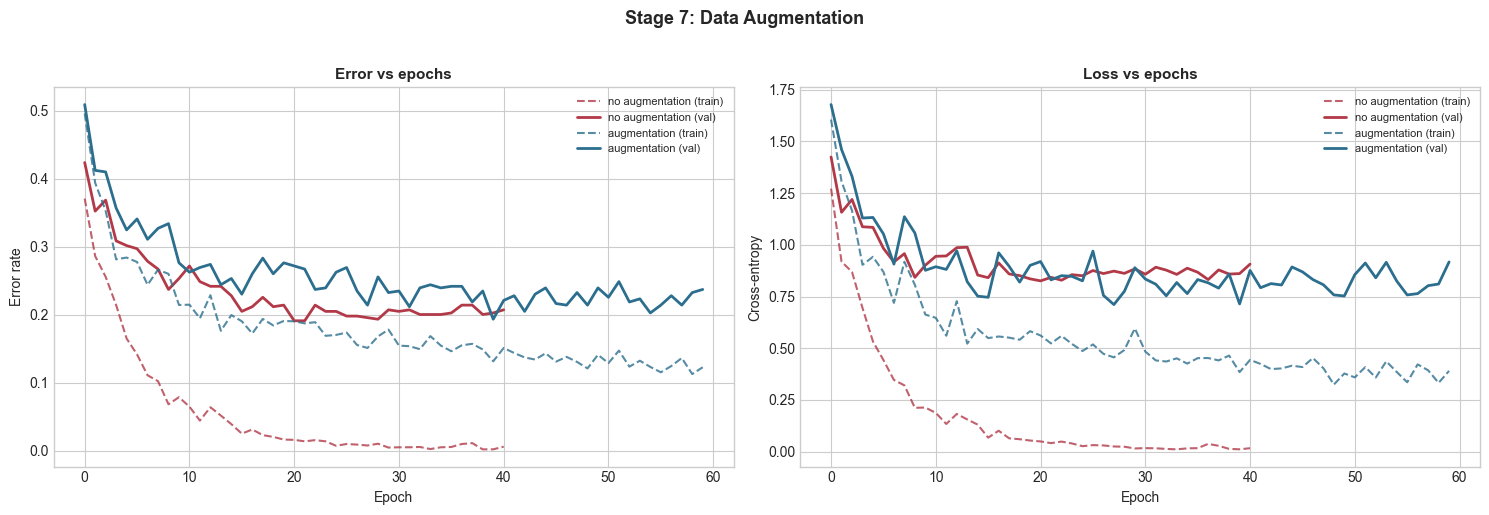

In [17]:
stage7 = [run_config(lbl, **{**BASE, "activation": best_act, "optimizer": best_opt, "lr": best_lr, "batch_size": best_bs, "hidden": best_arch, "loss": best_loss, "dropout": best_dropout, "weight_decay": best_wd, "augment": aug, "epochs": 120, "patience": 20}) for lbl, aug in [("no augmentation", False), ("augmentation", True)]]
stage7_df = show_table(stage7, "Stage 7: data augmentation (3 seeds, up to 120 epochs)")
best_aug = [False, True][int(np.argmax([r["Val accuracy (mean)"] for r in stage7]))]
print(f"Selected: augmentation = {best_aug}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for r, c in zip(stage7, ["#B23A48", "#2C6E8E"]):
    h = r["_runs"][0]["history"]
    axes[0].plot(h["train_err"], color=c, linestyle="--", alpha=0.8, label=f"{r['Config']} (train)"); axes[0].plot(h["val_err"], color=c, linewidth=2, label=f"{r['Config']} (val)")
    axes[1].plot(h["train_loss"], color=c, linestyle="--", alpha=0.8, label=f"{r['Config']} (train)"); axes[1].plot(h["val_loss"], color=c, linewidth=2, label=f"{r['Config']} (val)")
axes[0].set_title("Error vs epochs", fontsize=11, fontweight="bold"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Error rate"); axes[0].legend(fontsize=8)
axes[1].set_title("Loss vs epochs", fontsize=11, fontweight="bold"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Cross-entropy"); axes[1].legend(fontsize=8)
plt.suptitle("Stage 7: Data Augmentation", y=1.02, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "tuning_augmentation.png"), dpi=300, bbox_inches="tight")
plt.show()

##### Final MLP configuration and 5-fold cross-validation check
The selected hyperparameters are collected in one table. Before the single test evaluation, the final configuration is also run with stratified 5-fold cross-validation on the training plus validation data (each fold uses its held-out part for early stopping) to check that the chosen setting is stable.

In [18]:
FINAL = {**BASE, "activation": best_act, "optimizer": best_opt, "lr": best_lr, "batch_size": best_bs, "hidden": best_arch, "loss": best_loss, "dropout": best_dropout, "weight_decay": best_wd, "augment": best_aug, "epochs": 150, "patience": 20}
final_table = pd.DataFrame({"Hyperparameter": ["Hidden layers", "Activation", "Optimizer", "Learning rate", "Batch size", "Loss function", "Dropout", "Weight decay (L2)", "Data augmentation", "Max epochs / patience"],
                            "Selected value": [str(best_arch), best_act, best_opt, best_lr, best_bs, best_loss, best_dropout, best_wd, str(best_aug), "150 / 20"]})
print("Final MLP hyperparameters:")
display(final_table)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)
Xtv_t, ytv_t = torch.tensor(X_trval), torch.tensor(y_trval, dtype=torch.long)
cv_rows = []
for f, (tr_i, va_i) in enumerate(skf.split(X_trval, y_trval), 1):
    r = train_mlp(seed=f, Xtr=Xtv_t[tr_i], ytr=ytv_t[tr_i], Xva=Xtv_t[va_i], yva=ytv_t[va_i], **FINAL)
    cv_rows.append({"Fold": f, "Accuracy": r["val_acc"], "Best epoch": r["best_epoch"], "Time (s)": r["time"]})
cv_df = pd.DataFrame(cv_rows)
print("\n5-fold cross-validation of the final MLP configuration:")
display(cv_df.round(4))
print(f"Mean CV accuracy = {cv_df['Accuracy'].mean():.4f} +/- {cv_df['Accuracy'].std():.4f}")

Final MLP hyperparameters:


,Hyperparameter,Selected value
0,Hidden layers,"(256,)"
1,Activation,relu
2,Optimizer,sgd_momentum
3,Learning rate,0.05
4,Batch size,32
5,Loss function,cross_entropy
6,Dropout,0.0
7,Weight decay (L2),0.0001
8,Data augmentation,False
9,Max epochs / patience,150 / 20



5-fold cross-validation of the final MLP configuration:


,Fold,Accuracy,Best epoch,Time (s)
0,1,0.7619,14,1.2730
1,2,0.7656,22,1.6386
2,3,0.7949,37,2.1564
3,4,0.7780,25,1.8540
4,5,0.7431,11,1.2265


Mean CV accuracy = 0.7687 +/- 0.0192


##### Final MLP: training with early stopping and test evaluation

epoch   1: train loss 1.2993 err 0.3832 | val loss 1.4432 err 0.4401


epoch  10: train loss 0.2320 err 0.0750 | val loss 0.9616 err 0.2442


epoch  20: train loss 0.0477 err 0.0170 | val loss 0.8666 err 0.1982


epoch  30: train loss 0.0333 err 0.0096 | val loss 0.9080 err 0.2028


epoch  40: train loss 0.0111 err 0.0026 | val loss 0.9095 err 0.1797


...

epoch  60: train loss 0.0057 err 0.0009 | val loss 0.8951 err 0.1843


epoch  70: train loss 0.0080 err 0.0022 | val loss 0.8865 err 0.1866


epoch  80: train loss 0.0041 err 0.0000 | val loss 0.8871 err 0.1820



Best epoch = 66, epochs run = 86, training time = 3.8 s, parameters = 278,334
Train accuracy = 0.9956, validation accuracy = 0.8272

MLP test metrics:


,Model,Accuracy,Precision (macro),Recall (macro),F1 (macro),F1 (weighted),ROC-AUC (micro),ROC-AUC (macro)
0,MLP (tuned),0.7317,0.7492,0.7317,0.7305,0.7305,0.9841,0.9847


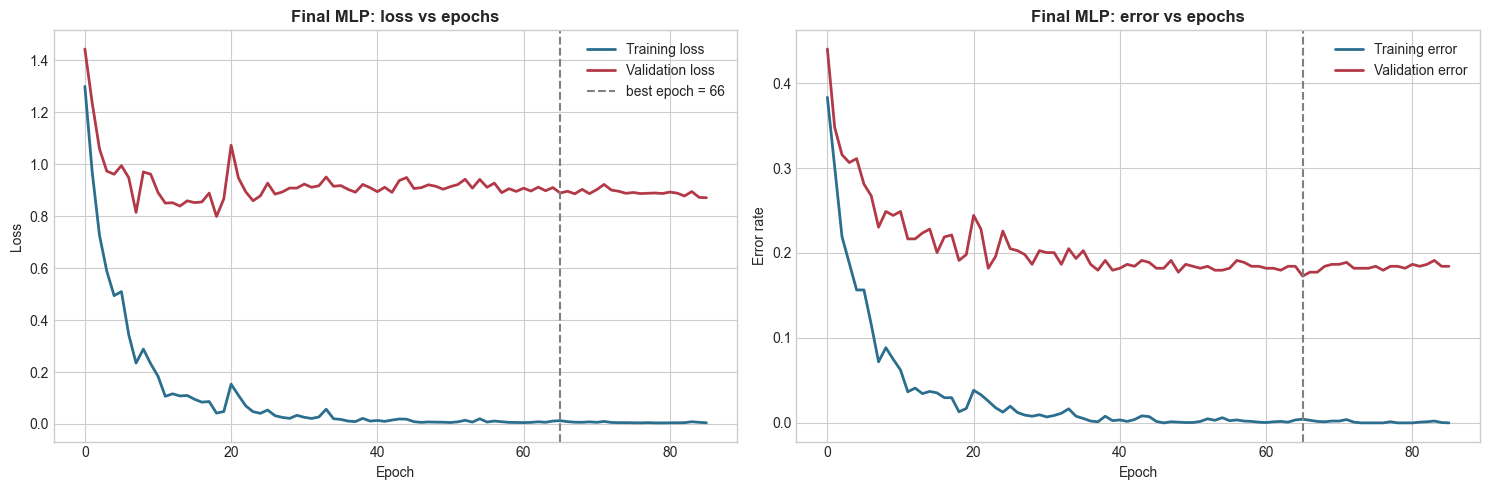

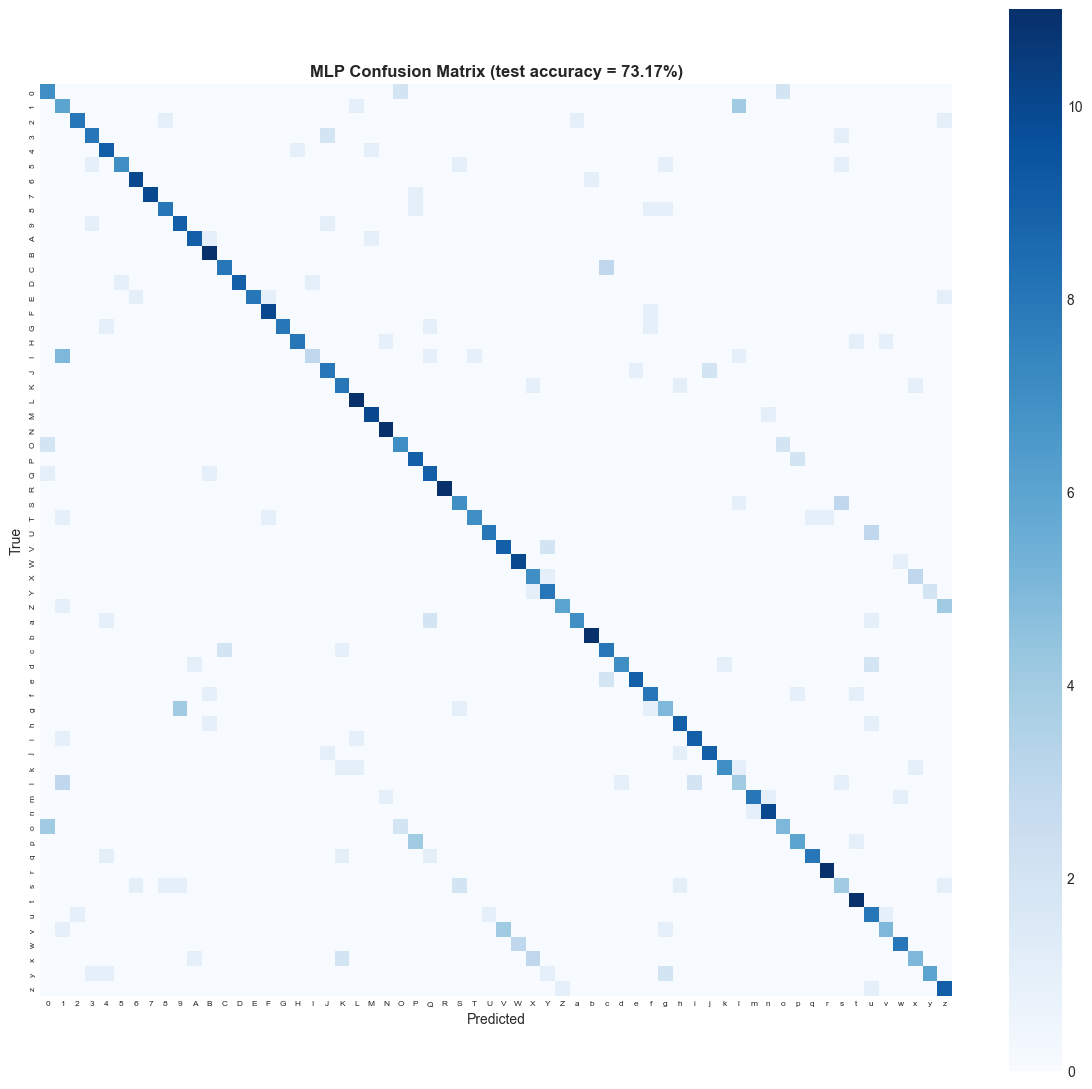

Most frequent MLP confusions:


,True,Predicted,Count
0,I,1,5
1,Z,z,4
2,v,V,4
3,o,0,4
4,p,P,4
5,g,9,4
6,1,l,4
7,l,1,3
8,C,c,3
9,w,W,3


In [19]:
final_run = train_mlp(seed=RNG, verbose=True, **FINAL)
mlp = final_run["model"]
print(f"\nBest epoch = {final_run['best_epoch']}, epochs run = {final_run['epochs_run']}, training time = {final_run['time']:.1f} s, parameters = {final_run['params']:,}")
print(f"Train accuracy = {final_run['train_acc']:.4f}, validation accuracy = {final_run['val_acc']:.4f}")

with torch.no_grad():
    mlp_logits = mlp(Xte_t)
mlp_scores = F.softmax(mlp_logits, dim=1).numpy()
mlp_pred = mlp_logits.argmax(1).numpy()
mlp_metrics = evaluate_model("MLP (tuned)", y_test, mlp_pred, mlp_scores)
print("\nMLP test metrics:")
display(pd.DataFrame([mlp_metrics]).round(4))

h = final_run["history"]
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(h["train_loss"], color="#2C6E8E", linewidth=2, label="Training loss"); axes[0].plot(h["val_loss"], color="#B23A48", linewidth=2, label="Validation loss")
axes[0].axvline(final_run["best_epoch"] - 1, color="gray", linestyle="--", label=f"best epoch = {final_run['best_epoch']}")
axes[0].set_title("Final MLP: loss vs epochs", fontsize=12, fontweight="bold"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()
axes[1].plot(h["train_err"], color="#2C6E8E", linewidth=2, label="Training error"); axes[1].plot(h["val_err"], color="#B23A48", linewidth=2, label="Validation error")
axes[1].axvline(final_run["best_epoch"] - 1, color="gray", linestyle="--")
axes[1].set_title("Final MLP: error vs epochs", fontsize=12, fontweight="bold"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Error rate"); axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "mlp_convergence.png"), dpi=300, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(12, 11))
cm_mlp = plot_confusion(ax, y_test, mlp_pred, f"MLP Confusion Matrix (test accuracy = {mlp_metrics['Accuracy']*100:.2f}%)")
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "mlp_confusion_matrix.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Most frequent MLP confusions:")
display(top_confusions(cm_mlp))

##### Untuned MLP baseline
To measure what tuning actually bought, the untuned baseline configuration (256 ReLU units, Adam 0.001, batch 64, no regularization) is also evaluated on the test set.

In [20]:
base_run = train_mlp(seed=RNG, **BASE)
with torch.no_grad():
    base_logits = base_run["model"](Xte_t)
base_scores = F.softmax(base_logits, dim=1).numpy()
base_pred = base_logits.argmax(1).numpy()
base_metrics = evaluate_model("MLP (untuned baseline)", y_test, base_pred, base_scores)
print(f"Baseline: best epoch = {base_run['best_epoch']}, train acc = {base_run['train_acc']:.4f}, val acc = {base_run['val_acc']:.4f}")
display(pd.DataFrame([base_metrics]).round(4))

Baseline: best epoch = 19, train acc = 0.9738, val acc = 0.7880


,Model,Accuracy,Precision (macro),Recall (macro),F1 (macro),F1 (weighted),ROC-AUC (micro),ROC-AUC (macro)
0,MLP (untuned baseline),0.7229,0.7388,0.7229,0.7218,0.7218,0.9858,0.9872


##### A/B comparison: PLA vs MLP
Test metrics side by side, micro and macro averaged ROC curves, confusion matrices, per-class F1 and the convergence curves of both models.

A/B comparison on the test set:


,Model,Accuracy,Precision (macro),Recall (macro),F1 (macro),F1 (weighted),ROC-AUC (micro),ROC-AUC (macro),Train accuracy,Parameters,Training time (s)
0,PLA,0.6437,0.6651,0.6437,0.6395,0.6395,0.9588,0.9600,0.9908,63550,3.3097
1,MLP (untuned baseline),0.7229,0.7388,0.7229,0.7218,0.7218,0.9858,0.9872,0.9738,278334,0.9306
2,MLP (tuned),0.7317,0.7492,0.7317,0.7305,0.7305,0.9841,0.9847,0.9956,278334,3.7850


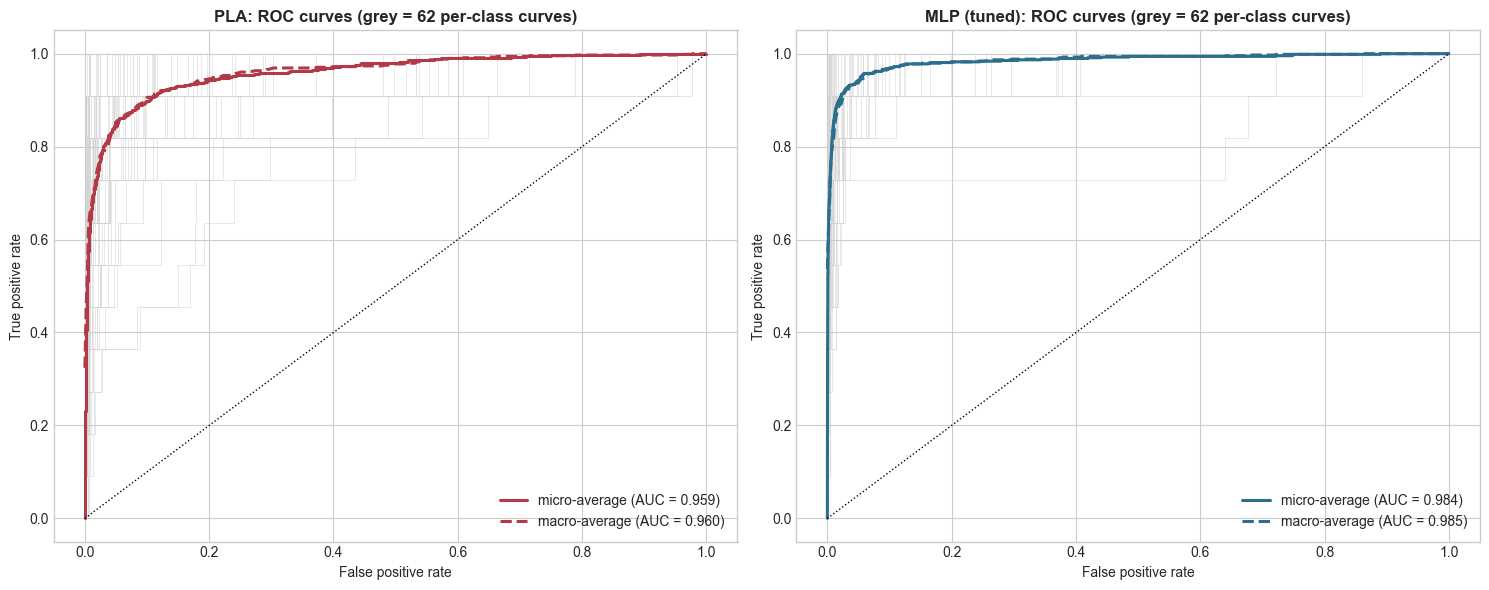

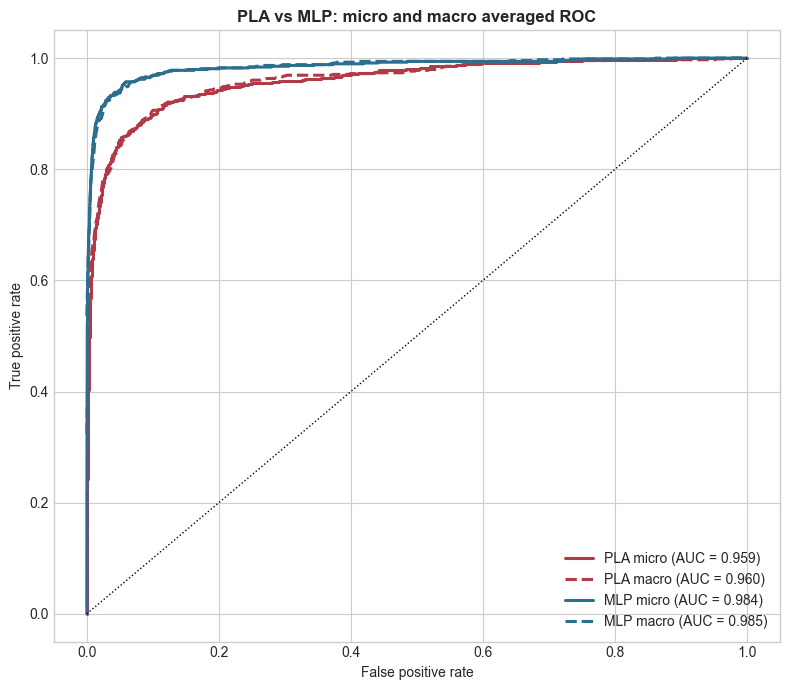

In [21]:
ab = pd.DataFrame([pla_metrics, base_metrics, mlp_metrics])
ab["Train accuracy"] = [accuracy_score(y_train, pla.predict(X_train)), base_run["train_acc"], final_run["train_acc"]]
ab["Parameters"] = [pla.W.size, base_run["params"], final_run["params"]]
ab["Training time (s)"] = [pla_time, base_run["time"], final_run["time"]]
ab.to_csv(os.path.join(IMG_DIR, "ab_comparison.csv"), index=False)
print("A/B comparison on the test set:")
display(ab.round(4))

pla_roc = roc_micro_macro(y_test, pla_scores)
mlp_roc = roc_micro_macro(y_test, mlp_scores)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, (mi, ma), name, c in zip(axes, [pla_roc, mlp_roc], ["PLA", "MLP (tuned)"], ["#B23A48", "#2C6E8E"]):
    ax.plot(mi[0], mi[1], color=c, linewidth=2.2, label=f"micro-average (AUC = {mi[2]:.3f})")
    ax.plot(ma[0], ma[1], color=c, linewidth=2.2, linestyle="--", label=f"macro-average (AUC = {ma[2]:.3f})")
    Y_bin = label_binarize(y_test, classes=np.arange(N_CLASSES))
    sc = pla_scores if name == "PLA" else mlp_scores
    for cidx in range(N_CLASSES):
        f_, t_, _ = roc_curve(Y_bin[:, cidx], sc[:, cidx]); ax.plot(f_, t_, color="lightgray", linewidth=0.6, alpha=0.6, zorder=0)
    ax.plot([0, 1], [0, 1], "k:", linewidth=1)
    ax.set_title(f"{name}: ROC curves (grey = 62 per-class curves)", fontsize=12, fontweight="bold"); ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate"); ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "roc_curves.png"), dpi=300, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(pla_roc[0][0], pla_roc[0][1], color="#B23A48", linewidth=2.2, label=f"PLA micro (AUC = {pla_roc[0][2]:.3f})")
ax.plot(pla_roc[1][0], pla_roc[1][1], color="#B23A48", linewidth=2.2, linestyle="--", label=f"PLA macro (AUC = {pla_roc[1][2]:.3f})")
ax.plot(mlp_roc[0][0], mlp_roc[0][1], color="#2C6E8E", linewidth=2.2, label=f"MLP micro (AUC = {mlp_roc[0][2]:.3f})")
ax.plot(mlp_roc[1][0], mlp_roc[1][1], color="#2C6E8E", linewidth=2.2, linestyle="--", label=f"MLP macro (AUC = {mlp_roc[1][2]:.3f})")
ax.plot([0, 1], [0, 1], "k:", linewidth=1)
ax.set_title("PLA vs MLP: micro and macro averaged ROC", fontsize=12, fontweight="bold"); ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate"); ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "roc_comparison.png"), dpi=300, bbox_inches="tight")
plt.show()

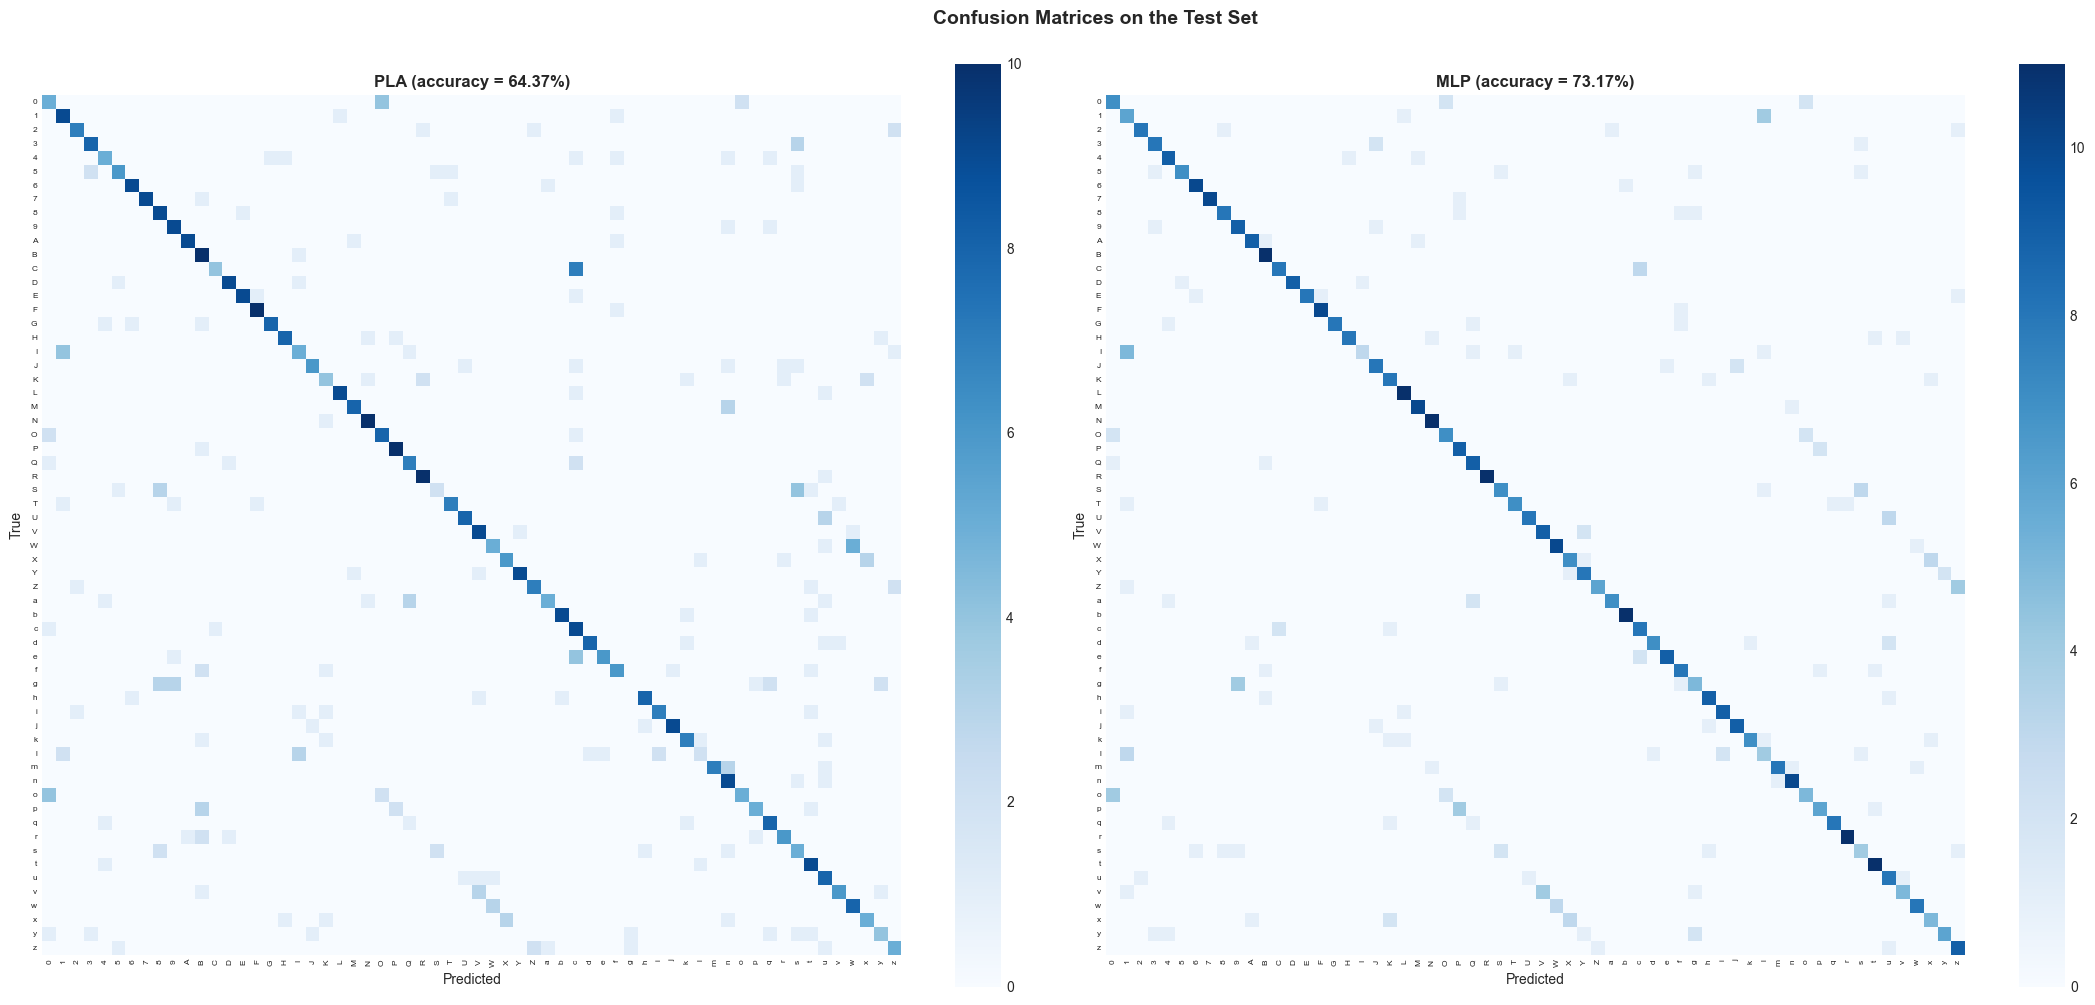

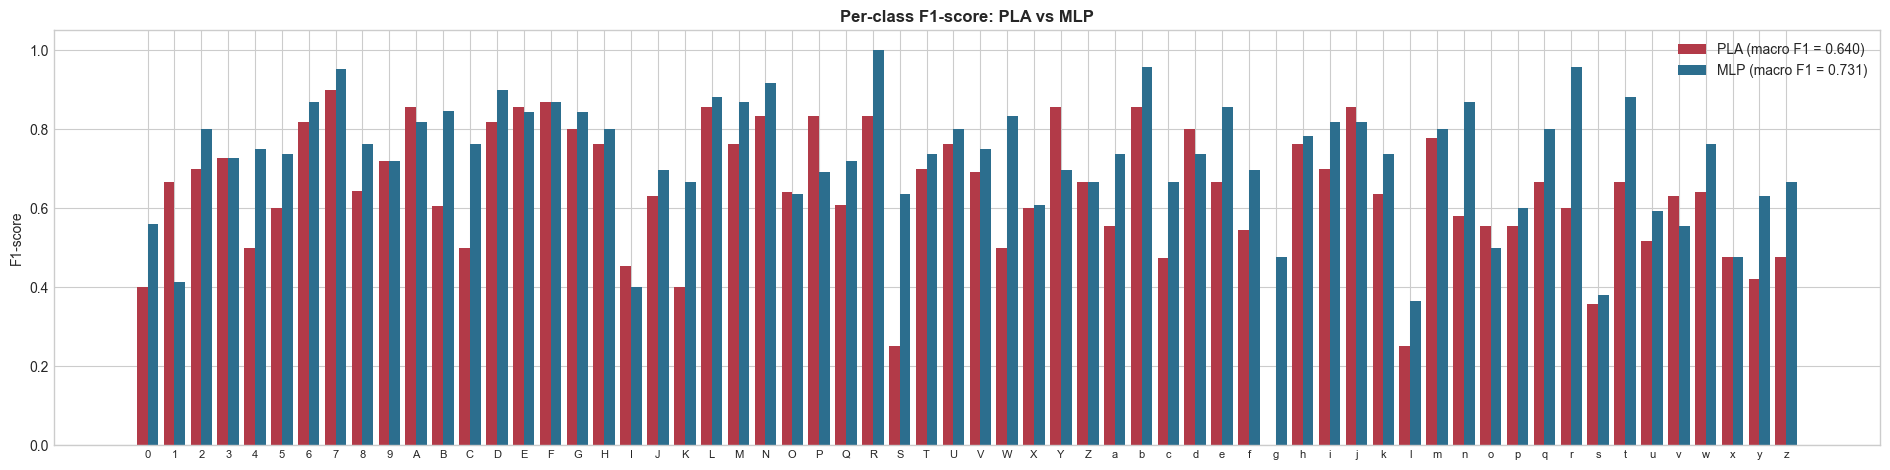

Mean F1 by class group:


,PLA F1,MLP F1
Group,,
digit,0.6675,0.7292
lower,0.5779,0.6968
upper,0.6905,0.7648


Classes where the MLP gains the most over the PLA:


,Class,Group,PLA F1,MLP F1,Gain
42,g,lower,0.000,0.476,0.476
28,S,upper,0.250,0.636,0.386
53,r,lower,0.600,0.957,0.357
32,W,upper,0.500,0.833,0.333
49,n,lower,0.581,0.870,0.289
20,K,upper,0.400,0.667,0.267
12,C,upper,0.500,0.762,0.262
4,4,digit,0.500,0.750,0.250


Hardest classes for both models (lowest MLP F1):


,Class,Group,PLA F1,MLP F1
47,l,lower,0.250,0.364
54,s,lower,0.357,0.381
18,I,upper,0.455,0.400
1,1,digit,0.667,0.414
42,g,lower,0.000,0.476
59,x,lower,0.476,0.476
50,o,lower,0.556,0.500
57,v,lower,0.632,0.556


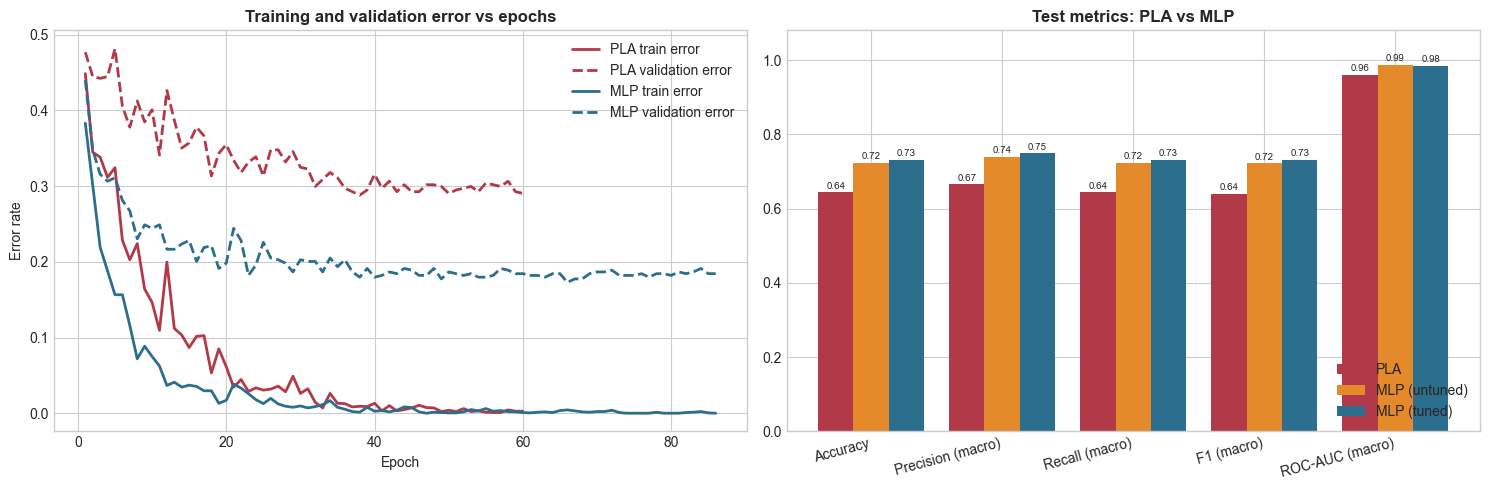

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(22, 10))
plot_confusion(axes[0], y_test, pla_pred, f"PLA (accuracy = {pla_metrics['Accuracy']*100:.2f}%)")
plot_confusion(axes[1], y_test, mlp_pred, f"MLP (accuracy = {mlp_metrics['Accuracy']*100:.2f}%)")
plt.suptitle("Confusion Matrices on the Test Set", y=1.0, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "confusion_matrices_ab.png"), dpi=300, bbox_inches="tight")
plt.show()

f1_pla = f1_score(y_test, pla_pred, average=None, zero_division=0)
f1_mlp = f1_score(y_test, mlp_pred, average=None, zero_division=0)
fig, ax = plt.subplots(figsize=(19, 4.8))
x = np.arange(N_CLASSES)
ax.bar(x - 0.2, f1_pla, 0.4, color="#B23A48", label=f"PLA (macro F1 = {f1_pla.mean():.3f})")
ax.bar(x + 0.2, f1_mlp, 0.4, color="#2C6E8E", label=f"MLP (macro F1 = {f1_mlp.mean():.3f})")
ax.set_xticks(x); ax.set_xticklabels(class_names, fontsize=8)
ax.set_title("Per-class F1-score: PLA vs MLP", fontsize=12, fontweight="bold"); ax.set_ylabel("F1-score"); ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "per_class_f1.png"), dpi=300, bbox_inches="tight")
plt.show()

per_class = pd.DataFrame({"Class": class_names, "Group": group, "PLA F1": f1_pla, "MLP F1": f1_mlp})
print("Mean F1 by class group:")
display(per_class.groupby("Group")[["PLA F1", "MLP F1"]].mean().round(4))
print("Classes where the MLP gains the most over the PLA:")
display(per_class.assign(Gain=per_class["MLP F1"] - per_class["PLA F1"]).sort_values("Gain", ascending=False).head(8).round(3))
print("Hardest classes for both models (lowest MLP F1):")
display(per_class.sort_values("MLP F1").head(8).round(3))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(np.arange(1, len(pla.history["train_err"]) + 1), pla.history["train_err"], color="#B23A48", linewidth=2, label="PLA train error")
axes[0].plot(np.arange(1, len(pla.history["val_err"]) + 1), pla.history["val_err"], color="#B23A48", linewidth=2, linestyle="--", label="PLA validation error")
axes[0].plot(np.arange(1, len(h["train_err"]) + 1), h["train_err"], color="#2C6E8E", linewidth=2, label="MLP train error")
axes[0].plot(np.arange(1, len(h["val_err"]) + 1), h["val_err"], color="#2C6E8E", linewidth=2, linestyle="--", label="MLP validation error")
axes[0].set_title("Training and validation error vs epochs", fontsize=12, fontweight="bold"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Error rate"); axes[0].legend()
metrics_plot = ["Accuracy", "Precision (macro)", "Recall (macro)", "F1 (macro)", "ROC-AUC (macro)"]
xm = np.arange(len(metrics_plot))
axes[1].bar(xm - 0.27, ab.loc[0, metrics_plot], 0.27, color="#B23A48", label="PLA")
axes[1].bar(xm, ab.loc[1, metrics_plot], 0.27, color="#E58A2A", label="MLP (untuned)")
axes[1].bar(xm + 0.27, ab.loc[2, metrics_plot], 0.27, color="#2C6E8E", label="MLP (tuned)")
for i, m in enumerate(metrics_plot):
    for off, row in zip([-0.27, 0, 0.27], [0, 1, 2]):
        axes[1].text(i + off, ab.loc[row, m] + 0.01, f"{ab.loc[row, m]:.2f}", ha="center", fontsize=7)
axes[1].set_xticks(xm); axes[1].set_xticklabels(metrics_plot, rotation=15, ha="right"); axes[1].set_ylim(0, 1.08)
axes[1].set_title("Test metrics: PLA vs MLP", fontsize=12, fontweight="bold"); axes[1].legend(loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "ab_summary.png"), dpi=300, bbox_inches="tight")
plt.show()

##### Observations and analysis

##### A/B result
- PLA: test accuracy 64.37%, macro F1 0.640, macro ROC-AUC 0.960. Tuned MLP: test accuracy 73.17%, macro F1 0.731, macro ROC-AUC 0.985. The MLP is 8.8 accuracy points and 9.1 macro F1 points better, and the gain is spread over all three class groups (lowercase F1 0.578 to 0.697, uppercase 0.691 to 0.765, digits 0.668 to 0.729)
- Both models make the same kind of mistakes, which are case pairs and look-alike characters: I/1/l, o/0/O, C/c, S/s, Z/z, W/w, V/v, g/9. These pairs are nearly identical after cropping and resizing, so no classifier that only sees the 32 x 32 image can fully separate them
- The untuned MLP baseline already reached 72.29% on the test set. Tuning raised validation accuracy from 78.8% to 82.7% but only added 0.9 points on the 682-image test set, so most of the PLA to MLP gap comes from the hidden layer itself rather than from tuning

##### Why does PLA underperform compared to MLP?
- The PLA is a linear classifier: each of the 62 units draws one hyperplane in pixel space, and the 62 classes overlap heavily in that space (the PCA scatter shows the groups sitting on top of each other), so no set of hyperplanes separates them and the update rule never settles. After 60 epochs it was still making 19 updates per epoch and the validation error kept oscillating between 29% and 35%
- It still reached 99.1% training accuracy because 2,294 samples in 1,025 dimensions are almost linearly separable, but this is memorisation. The PLA has no notion of margin, so its hyperplanes sit right next to training points and do not transfer to new handwriting, which gives the 35-point gap between train and test accuracy
- The MLP's hidden layer learns 256 stroke-like features and combines them non-linearly, which lets it build curved decision boundaries and share features between classes. Its ROC-AUC (0.985 versus 0.960) shows that its scores rank the correct class higher far more consistently, even when the top-1 prediction is wrong
- With zero initial weights the PLA was completely insensitive to the learning rate: eta of 0.01, 0.1, 1 and 10 gave identical error curves and only scaled the weights, so there is nothing to tune in the PLA that could close the gap

##### Which hyperparameters had the most impact on MLP performance?
- Batch size and learning rate together mattered most. Batch 16 with lr = 0.05 and momentum was unstable (training loss stuck between 1.2 and 2.1, validation accuracy 60.0%), while batch 32 to 64 gave 80.7% to 81.3% and batch 256 dropped to 78.0%, a spread of 21 points
- Optimizer and learning rate: across the 12 optimizer and learning rate combinations validation accuracy ranged from 72.96% (SGD, lr 0.01) to 80.65% (SGD with momentum, lr 0.05), a spread of 7.7 points
- Depth: one hidden layer of 256 units (81.3%) beat every deeper network; the three-layer (512, 256, 128) network reached only 74.1%, a 7-point drop
- Regularization: dropout hurt (0.2 gave 78.7%, 0.4 gave 70.9%) while weight decay 1e-4 gave a small gain (81.6% versus 81.3%). Loss function (cross-entropy 81.3% versus MSE 79.1%) and activation (ReLU 79.7%, tanh 79.7%, sigmoid 78.9%) mattered least

##### Did optimizer choice (SGD vs Adam) affect convergence?
- Yes. Adam at lr = 0.001 reached its best validation accuracy in about 22 epochs, while plain SGD at lr = 0.01 needed 52 epochs and still ended 7 points lower (73.0%). SGD needed a learning rate 30 times larger (0.3) to match Adam, which shows how much Adam's per-parameter step size helps on raw pixel inputs
- Adam was also much less sensitive to the learning rate: over a 50-fold range (1e-4 to 5e-3) its validation accuracy stayed between 76.4% and 79.7%, whereas SGD moved from 73.0% to 80.2% over a 30-fold range
- SGD with momentum 0.9 at lr = 0.05 was the best optimizer overall (80.65% with the smallest seed-to-seed spread of 0.2%) and converged in about 29 epochs. Momentum gives most of Adam's speed and, on this small dataset, generalised slightly better, which is why it was kept for the final model

##### Did adding more hidden layers always improve results? Why or why not?
- No. Every deeper network was worse than the single 256-unit layer: (256, 128) 75.8%, (512, 256) 79.6%, (512, 256, 128) 74.1% and (256, 256, 256) 75.1%. Making the single layer wider (512 or 1,024 units) changed nothing (81.0%)
- With only 2,294 training images, extra layers add parameters and non-linearity that the data cannot constrain, and they also made optimisation harder: the deeper networks stopped at lower training accuracy (87% to 91%) and earlier best epochs, meaning the plain momentum SGD setting tuned for one layer was no longer ideal. A flattened 32 x 32 image is a low-level input and one hidden layer is enough to learn stroke detectors for it; deeper models only pay off with more data or with convolutional layers that reuse weights across positions

##### Did MLP show overfitting? How could it be mitigated?
- Yes, strongly. The final model reached 99.6% training accuracy but 82.7% validation and 73.2% test accuracy, and the validation loss bottomed out around epoch 20 (0.87) and then drifted upwards while the training loss kept falling to 0.004. The 5-fold cross-validation estimate of 76.9% +/- 1.9% confirms that the true generalisation is well below the training score
- Early stopping on the validation error was used throughout and restores the weights of the best epoch. Weight decay 1e-4 helped marginally. Dropout did not help: with one 256-unit layer and 37 images per class, dropout of 0.4 removed too much capacity and the model underfit (83% training accuracy)
- Data augmentation (random rotation, scaling and shifts every epoch) shrank the train to validation gap from 17.5 to 5.8 points, so it clearly reduced overfitting, but validation accuracy stayed at 80.5% and it was not selected. The remaining errors are mostly ambiguous case pairs, which no regularizer can fix
- The realistic ways to go further are more training data per class, a convolutional network that is invariant to small shifts and strokes, or hand-crafted features such as HOG in place of raw pixels

##### Summary
- Final MLP: one hidden layer of 256 ReLU units, SGD with momentum 0.9, learning rate 0.05, batch size 32, cross-entropy loss, weight decay 1e-4, early stopping (best epoch 66), 278,334 parameters, 3.8 s training time
- PLA versus MLP on the test set: accuracy 64.37% versus 73.17%, macro F1 0.640 versus 0.731, micro ROC-AUC 0.959 versus 0.984. The MLP wins because its hidden layer gives it non-linear decision boundaries, and hyperparameter tuning made its convergence faster and more stable rather than dramatically changing its accuracy